In [1]:
# !pip install -q ultralytics
# !pip install -q easyocr
# !pip install -q simple-lama-inpainting

In [1]:
import os
import json
import gc
import re
import cv2
import random

from pathlib import Path
import shutil
import yaml
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from typing import Dict, List, Tuple, Optional
from PIL import Image, ImageDraw, ImageFont

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

from ultralytics import YOLO
import easyocr


PATH_TO_IMAGE=r'./dataset/image/One Piece (41).jpg'

In [2]:
def clear_memory():

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("memory cleared")

In [3]:
def coco_to_yolo_seg(coco_json, img_dir, output_dir, label_map={'bubble': 0, 'sfx_text': 1}):
    with open(coco_json) as f:
        data = json.load(f)

    os.makedirs(output_dir, exist_ok=True)

    images = {img['id']: img for img in data['images']}

    anns_by_image = {}
    for ann in data['annotations']:
        if not ann.get('segmentation'):
            continue
        img_id = ann['image_id']
        anns_by_image.setdefault(img_id, []).append(ann)

    for img_id, anns in anns_by_image.items():
        img_info = images[img_id]
        w, h = img_info['width'], img_info['height']
        filename = img_info['file_name']
        stem = Path(filename).stem

        yolo_lines = []
        for ann in anns:
            cat_id = ann['category_id']
            cat_name = None
            for cat in data['categories']:
                if cat['id'] == cat_id:
                    cat_name = cat['name']
                    break
            if cat_name not in label_map:
                continue
            class_idx = label_map[cat_name]

            segs = ann['segmentation']
            for seg in segs:
                if len(seg) < 6: 
                    continue
                norm_seg = []
                points = zip(seg[0::2], seg[1::2])  # пары x,y
                for x, y in points:
                    norm_seg.append(x / w)
                    norm_seg.append(y / h)
                yolo_lines.append(f"{class_idx} " + " ".join(f"{c:.6f}" for c in norm_seg))

        if yolo_lines:
            txt_path = os.path.join(output_dir, f"{stem}.txt")
            with open(txt_path, 'w') as f:
                f.write("\n".join(yolo_lines))
    print("Конвертация завершена!")


coco_to_yolo_seg(
    coco_json='./dataset/annotations/instances_default.json',
    img_dir='image',                
    output_dir='yolo_labels'        
)

Конвертация завершена!


In [4]:
class MangaDataset(Dataset):
    """
    PyTorch Dataset для загрузки изображений манги с полигональными аннотациями.
    
    При инициализации создаёт структуру датасета в data/ с разбиением на train/val/test
    и файлом data.yaml.
    """

    def __init__(
        self,
        dataset_path: str,
        split: str = 'all',
        train_ratio: float = 0.7,
        val_ratio: float = 0.15,
        seed: int = 42
    ):
        self.dataset_path = Path(dataset_path)
        self.images_dir = self.dataset_path / 'image'
        self.labels_dir = self.dataset_path / 'yolo_labels'
        self.split = split

        assert self.images_dir.exists(), f"Нет папки: {self.images_dir}"
        assert self.labels_dir.exists(), f"Нет папки: {self.labels_dir}"

        self.classes = {
            0: 'bubble',
            1: 'sfx_text',
            2: 'background_text'
        }
        self.num_classes = len(self.classes)

        self.class_colors = {
            0: (0.2, 0.4, 1.0),
            1: (1.0, 0.2, 0.2),
            2: (0.2, 0.8, 0.2)
        }

        self.samples = self._collect_samples()
        print(f"📦 Найдено {len(self.samples)} изображений с аннотациями")


        if split != 'all':
            self.samples = self._split_samples(train_ratio, val_ratio, seed)
            print(f"   Режим '{split}': {len(self.samples)} изображений")

        self.data_dir = self.dataset_path.parent / 'data'
        self._build_dataset(train_ratio, val_ratio, seed)

    def _collect_samples(self) -> List[Dict[str, Path]]:
        """Находит все пары изображение-аннотация"""
        samples = []
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp', '*.bmp']:
            image_files.extend(self.images_dir.glob(ext))

        for img_path in sorted(image_files):
            label_path = self.labels_dir / (img_path.stem + '.txt')
            if label_path.exists():
                with open(label_path, 'r') as f:
                    if f.read().strip():
                        samples.append({'image': img_path, 'label': label_path})
                    else:
                        print(f"⚠️  Пустая аннотация: {label_path.name}")
            else:
                print(f"⚠️  Нет аннотации: {img_path.name}")

        return samples

    def _split_samples(self, train_ratio: float, val_ratio: float, seed: int) -> List[Dict]:
        """Разбивает на train/val/test"""
        random.seed(seed)
        indices = list(range(len(self.samples)))
        random.shuffle(indices)

        n = len(indices)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        if self.split == 'train':
            selected = indices[:n_train]
        elif self.split == 'val':
            selected = indices[n_train:n_train + n_val]
        elif self.split == 'test':
            selected = indices[n_train + n_val:]
        else:
            raise ValueError(f"Неизвестный split: {self.split}")

        return [self.samples[i] for i in selected]

    def _build_dataset(self, train_ratio: float, val_ratio: float, seed: int):
        """
        Создаёт структуру датасета:
        data/
        ├── train/
        │   ├── images/
        │   └── labels/
        ├── val/
        │   ├── images/
        │   └── labels/
        ├── test/
        │   ├── images/
        │   └── labels/
        └── data.yaml
        """
        if self.data_dir.exists():
            shutil.rmtree(self.data_dir)

        random.seed(seed)
        indices = list(range(len(self._collect_samples())))
        random.shuffle(indices)
        all_samples = self._collect_samples()

        n = len(all_samples)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        splits = {
            'train': [all_samples[i] for i in indices[:n_train]],
            'val': [all_samples[i] for i in indices[n_train:n_train + n_val]],
            'test': [all_samples[i] for i in indices[n_train + n_val:]]
        }

        for split_name, split_samples in splits.items():
            img_dir = self.data_dir / split_name / 'images'
            lbl_dir = self.data_dir / split_name / 'labels'
            img_dir.mkdir(parents=True, exist_ok=True)
            lbl_dir.mkdir(parents=True, exist_ok=True)

            for sample in split_samples:
                safe_name = sample['image'].stem
                for char in [' ', '(', ')', '[', ']', '&', "'", '"']:
                    safe_name = safe_name.replace(char, '_')

                shutil.copy2(sample['image'], img_dir / f"{safe_name}{sample['image'].suffix}")
                shutil.copy2(sample['label'], lbl_dir / f"{safe_name}.txt")

        print(str(self.data_dir.absolute()))
        config = {
            'path': str(self.data_dir.absolute()),
            'train': 'train/images',
            'val': 'val/images',
            'test': 'test/images',
            'names': self.classes
        }

        yaml_path = self.data_dir / 'data.yaml'
        with open(yaml_path, 'w') as f:
            yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

        print(f"✅ Датасет создан: {self.data_dir}")
        print(f"   train: {len(splits['train'])} | val: {len(splits['val'])} | test: {len(splits['test'])}")
        print(f"   Конфиг: {yaml_path}")

    def _parse_yolo_annotation(self, label_path: Path, w: int, h: int) -> Dict:
        """Парсит YOLO-аннотацию в абсолютные координаты"""
        polygons, labels, boxes = [], [], []

        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue

                class_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]

                abs_points = []
                for i in range(0, len(coords), 2):
                    abs_points.append([coords[i] * w, coords[i + 1] * h])

                abs_points = np.array(abs_points, dtype=np.float32)

                polygons.append(abs_points)
                labels.append(class_id)
                boxes.append([
                    abs_points[:, 0].min(), abs_points[:, 1].min(),
                    abs_points[:, 0].max(), abs_points[:, 1].max()
                ])

        masks = np.zeros((len(polygons), h, w), dtype=np.uint8)
        for i, poly in enumerate(polygons):
            cv2.fillPoly(masks[i], [poly.astype(np.int32)], 1)

        return {
            'polygons': polygons,
            'boxes': np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4)),
            'labels': np.array(labels, dtype=np.int64),
            'masks': masks
        }

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict:
        sample = self.samples[idx]
        image = cv2.imread(str(sample['image']))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        target = self._parse_yolo_annotation(sample['label'], w, h)

        return {
            'image': image,
            'target': target,
            'image_path': str(sample['image']),
            'size': (h, w)
        }

    def visualize(self, idx: Optional[int] = None, image_path: Optional[str] = None, save_path: Optional[str] = None):
        """
        Визуализирует один сэмпл.

        Аргументы:
            idx: индекс сэмпла (если None — случайный)
            image_path: путь к конкретному изображению
            save_path: сохранить визуализацию
        """
        if image_path:
            found = False
            for i, s in enumerate(self.samples):
                if s['image'].name == Path(image_path).name:
                    idx = i
                    found = True
                    break
            if not found:
                raise ValueError(f"Изображение не найдено: {image_path}")

        if idx is None:
            idx = random.randint(0, len(self) - 1)

        sample = self[idx]
        image = sample['image'].copy()
        target = sample['target']
        h, w = sample['size']

        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        ax.imshow(image)
        
        for i, poly in enumerate(target['polygons']):
            class_id = target['labels'][i]
            color = self.class_colors.get(class_id, (1, 1, 1))
            name = self.classes[class_id]

            patch = Polygon(poly, closed=True, facecolor=color, edgecolor=color, alpha=0.3, linewidth=2)
            ax.add_patch(patch)

            center = poly.mean(axis=0)
            ax.text(center[0], center[1], name, ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

        unique, counts = np.unique(target['labels'], return_counts=True)
        stats = "\n".join([f"  {self.classes[c]}: {cnt}" for c, cnt in zip(unique, counts)])

        ax.set_title(f"{Path(sample['image_path']).name} | {w}×{h}\n{stats}", fontsize=11)
        ax.axis('off')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ {save_path}")

        plt.show()

        print(f"\n📷 {Path(sample['image_path']).name}")
        print(f"   Размер: {w}×{h} | Объектов: {len(target['polygons'])}")
        for c, cnt in zip(unique, counts):
            print(f"   {self.classes[c]}: {cnt}")

    def print_statistics(self):
        """Выводит статистику датасета"""
        distribution = {name: 0 for name in self.classes.values()}
        for s in self.samples:
            target = self._parse_yolo_annotation(s['label'], 1, 1)
            for l in target['labels']:
                distribution[self.classes[l]] += 1

        total = sum(distribution.values())

        print(f"\n📦 СТАТИСТИКА")
        print(f"   Режим: {self.split}")
        print(f"   Изображений: {len(self.samples)}")
        print(f"   Объектов: {total}")
        for name, count in distribution.items():
            print(f"   {name}: {count} ({count/total*100:.1f}%)" if total else f"   {name}: 0")
        print(f"   Среднее объектов/изобр: {total/len(self.samples):.1f}" if self.samples else "")


⚠️  Нет аннотации: Gachi Akuta (16).jpg
⚠️  Нет аннотации: Gachi Akuta (19).jpg
⚠️  Нет аннотации: Gachi Akuta (32).jpg
⚠️  Нет аннотации: Gachi Akuta (33).jpg
⚠️  Нет аннотации: Gachi Akuta (34).jpg
⚠️  Нет аннотации: Gachi Akuta (37).jpg
⚠️  Нет аннотации: Gachi Akuta (8).jpg
⚠️  Нет аннотации: One Piece (49).jpg
⚠️  Нет аннотации: OneOunch_19.jpg
⚠️  Нет аннотации: OneOunch_20.jpg
⚠️  Нет аннотации: OneOunch_23.jpg
⚠️  Нет аннотации: The cradle of the sea (2).jpg
⚠️  Нет аннотации: The cradle of the sea (29).jpg
⚠️  Нет аннотации: The cradle of the sea (30).jpg
⚠️  Нет аннотации: The cradle of the sea (31).jpg
⚠️  Нет аннотации: The cradle of the sea (32).jpg
⚠️  Нет аннотации: The cradle of the sea (33).jpg
⚠️  Нет аннотации: The cradle of the sea (34).jpg
⚠️  Нет аннотации: The cradle of the sea (38).jpg
⚠️  Нет аннотации: The cradle of the sea (42).jpg
⚠️  Нет аннотации: The cradle of the sea (74).jpg
📦 Найдено 188 изображений с аннотациями
   Режим 'train': 131 изображений
⚠️  Н

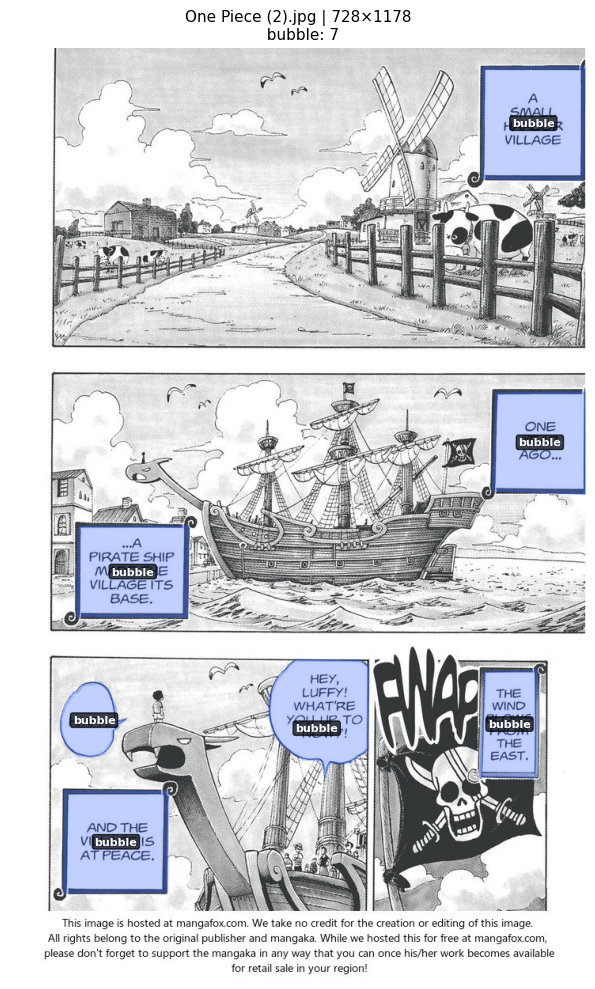


📷 One Piece (2).jpg
   Размер: 728×1178 | Объектов: 7
   bubble: 7


In [5]:
dataset = MangaDataset(
    dataset_path='./dataset',
    split='train',
    train_ratio=0.7,
    val_ratio=0.15,
    seed=42
)


dataset.print_statistics()


dataset.visualize()
# dataset.visualize(image_path='/content/image/One Piece (41).jpg')

In [6]:
class MangaBubbleDetector:
    """
    Детектор текстовых элементов манги на основе YOLOv8-seg.
    
    Использует готовую структуру датасета от MangaDataset.
    Основной метод — predict_single() для одного изображения,
    результат сразу готов для OCR и перевода.
    """

    def __init__(self, model_size: str = 'nano'):
        model_map = {
            'nano': 'yolov8n-seg.pt',
            'small': 'yolov8s-seg.pt',
            'medium': 'yolov8m-seg.pt',
        }

        self.model_name = model_map.get(model_size, 'yolov8n-seg.pt')
        self.model_size = model_size
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = YOLO(self.model_name)

        self.class_names = {
            0: 'bubble',
            1: 'sfx_text',
            2: 'background_text'
        }

        self.colors = {
            0: (255, 50, 50),
            1: (50, 50, 255),
            2: (50, 255, 50)
        }

        print(f"🚀 Детектор YOLOv8-{model_size}-seg | {self.device}")

    def train(
        self,
        yaml_path: str,
        epochs: int = 100,
        imgsz: int = 640,
        batch: int = 8,
        use_augmentation: bool = False,
        **kwargs
    ):
        """
        Обучает модель, используя готовый data.yaml от MangaDataset.

        Args:
            yaml_path: путь к data.yaml
            epochs: количество эпох
            imgsz: размер изображений
            batch: размер батча
            use_augmentation: включить лёгкие аугментации
        """
        print(f"\n🎯 Обучение: {epochs} эпох, batch={batch}, imgsz={imgsz}")
        print(f"   Аугментации: {'вкл' if use_augmentation else 'выкл'}")
        print(yaml_path)

        train_args = {
            'data': yaml_path,
            'epochs': epochs,
            'imgsz': imgsz,
            'batch': batch,
            'device': self.device,
            'lr0': 0.001,
            'lrf': 0.01,
            'momentum': 0.937,
            'weight_decay': 0.0005,
            'warmup_epochs': 3,
            'optimizer': 'SGD',
            'cos_lr': True,
            'box': 7.5,
            'cls': 0.5,
            'dfl': 1.5,
            'overlap_mask': True,
            'mask_ratio': 4,
            'save': True,
            'save_period': 10,
            'patience': 50,
            'pretrained': True,
            'seed': 42,
            'project': 'manga_detector',
            'name': f'manga_{self.model_size}',
            'exist_ok': True,
            'verbose': True,
            'plots': True,
        }

        if use_augmentation:
            train_args.update({
                'hsv_h': 0.01, 'hsv_s': 0.3, 'hsv_v': 0.2,
                'degrees': 5.0, 'translate': 0.05, 'scale': 0.3, 'shear': 1.0,
                'flipud': 0.0, 'fliplr': 0.3,
                'mosaic': 0.3, 'mixup': 0.05, 'copy_paste': 0.05,
                'close_mosaic': 5,
            })
        else:
            train_args.update({
                'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.0,
                'degrees': 0.0, 'translate': 0.0, 'scale': 0.0, 'shear': 0.0,
                'flipud': 0.0, 'fliplr': 0.0,
                'mosaic': 0.0, 'mixup': 0.0, 'copy_paste': 0.0,
            })

        train_args.update(kwargs)

        self.model.train(**train_args)

        best_path = Path('manga_detector') / f'manga_{self.model_size}' / 'weights' / 'best.pt'
        if best_path.exists():
            self.model = YOLO(str(best_path))
            print(f"✅ Лучшая модель: {best_path}")

        print("✅ Обучение завершено")


    def validate(self, yaml_path: str) -> Dict:
        """
        Валидация модели.

        Args:
            yaml_path: путь к data.yaml

        Returns:
            словарь с метриками
        """
        print(f"\n📊 Валидация: {yaml_path}")

        metrics = self.model.val(data=yaml_path, split='val', device=self.device)

        results = {}
        if hasattr(metrics, 'box') and metrics.box is not None:
            results['box_p'] = float(metrics.box.p)
            results['box_r'] = float(metrics.box.r)
            results['box_map50'] = float(metrics.box.map50)
            results['box_map'] = float(metrics.box.map)
            print(f"   Box: P={results['box_p']:.3f} R={results['box_r']:.3f} "
                  f"mAP50={results['box_map50']:.3f} mAP={results['box_map']:.3f}")

        if hasattr(metrics, 'seg') and metrics.seg is not None:
            results['mask_p'] = float(metrics.seg.p)
            results['mask_r'] = float(metrics.seg.r)
            results['mask_map50'] = float(metrics.seg.map50)
            results['mask_map'] = float(metrics.seg.map)
            print(f"   Mask: P={results['mask_p']:.3f} R={results['mask_r']:.3f} "
                  f"mAP50={results['mask_map50']:.3f} mAP={results['mask_map']:.3f}")

        return results

    def predict(self, image_path: str, conf: float = 0.25) -> Dict:
        """
        Предсказание на одном изображении.
        Возвращает структуру, готовую для OCR.

        Args:
            image_path: путь к изображению
            conf: порог уверенности

        Returns:
            {
                'image': np.ndarray (RGB),
                'size': (w, h),
                'objects': [
                    {
                        'class_id': int,
                        'class_name': str,
                        'confidence': float,
                        'bbox': [x1, y1, x2, y2],
                        'mask': np.ndarray (бинарная, h×w),
                    },
                    ...
                ]
            }
        """
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Не удалось загрузить: {image_path}")

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]

        results = self.model.predict(source=image_path, conf=conf, device=self.device, verbose=False)
        result = results[0]

        objects = []

        if result.masks is not None:
            masks = result.masks.data.cpu().numpy()

            for i in range(len(masks)):
                mask = masks[i]

                cls_val = result.boxes.cls[i]
                conf_val = result.boxes.conf[i]
                xyxy = result.boxes.xyxy[i]

                class_id = int(cls_val.item()) if hasattr(cls_val, 'item') else int(cls_val)
                confidence = float(conf_val.item()) if hasattr(conf_val, 'item') else float(conf_val)
                bbox = [float(x.item()) if hasattr(x, 'item') else float(x) for x in xyxy]

                mask_resized = cv2.resize(mask, (w, h))
                mask_binary = (mask_resized > 0.5).astype(np.uint8)

                objects.append({
                    'class_id': class_id,
                    'class_name': self.class_names.get(class_id, 'unknown'),
                    'confidence': confidence,
                    'bbox': bbox,
                    'mask': mask_binary,
                })

        objects.sort(key=lambda o: (o['bbox'][1], o['bbox'][0]))

        return {
            'image': image_rgb,
            'size': (w, h),
            'objects': objects,
        }


    def draw_predictions(self, predictions: Dict) -> np.ndarray:
        """Рисует предсказания на изображении."""
        vis = predictions['image'].copy()

        for obj in predictions['objects']:
            color = self.colors.get(obj['class_id'], (255, 255, 0))

            mask = obj['mask']
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                overlay = vis.copy()
                cv2.fillPoly(overlay, [cnt], color)
                cv2.addWeighted(overlay, 0.3, vis, 0.7, 0, vis)
                cv2.polylines(vis, [cnt], True, color, 2)

            x1, y1, x2, y2 = map(int, obj['bbox'])
            cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

            label = f"{obj['class_name']} {obj['confidence']:.2f}"
            cv2.putText(vis, label, (x1, max(y1 - 5, 15)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        return vis

    def compare_with_gt(self, image_path: str, label_path: str, conf: float = 0.25):
        """Сравнивает предсказания с ground truth (визуализация)."""

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        preds = self.predict(image_path, conf=conf)
        pred_vis = self.draw_predictions(preds)

        gt_vis = image.copy()
        gt_count = 0
        if Path(label_path).exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 7:
                        class_id = int(parts[0])
                        coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                        coords[:, 0] *= w
                        coords[:, 1] *= h
                        coords = coords.astype(np.int32)

                        color = self.colors.get(class_id, (255, 255, 0))
                        overlay = gt_vis.copy()
                        cv2.fillPoly(overlay, [coords], color)
                        cv2.addWeighted(overlay, 0.3, gt_vis, 0.7, 0, gt_vis)
                        cv2.polylines(gt_vis, [coords], True, color, 2)
                        gt_count += 1

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(image); axes[0].set_title('Оригинал'); axes[0].axis('off')
        axes[1].imshow(gt_vis); axes[1].set_title(f'GT ({gt_count})'); axes[1].axis('off')
        axes[2].imshow(pred_vis); axes[2].set_title(f'Pred ({len(preds["objects"])})'); axes[2].axis('off')
        plt.tight_layout()
        plt.show()

        return preds

    def save(self, path: str = 'manga_detector.pt'):
        folder_path = Path(path).parent
        folder_path.mkdir(parents=True, exist_ok=True)
        self.model.save(path)
            

    def load(self, path: str):
        p = Path(path)
        if p.exists():
            self.model = YOLO(str(p))
            print(f"📂 Модель загружена: {p}")
        else:
            raise FileNotFoundError(f"Файл модели не найден: {path}")

In [7]:
str(dataset.data_dir / 'data.yaml')

'data\\data.yaml'

In [8]:
detector = MangaBubbleDetector(model_size='small')
detector.train(yaml_path=str(dataset.data_dir / 'data.yaml'), epochs=100)

# Валидируем
detector.validate(yaml_path=str(dataset.data_dir / 'data.yaml'))

🚀 Детектор YOLOv8-small-seg | cuda

🎯 Обучение: 100 эпох, batch=8, imgsz=640
   Аугментации: выкл
data\data.yaml
New https://pypi.org/project/ultralytics/8.4.110 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.98  Python-3.10.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12281MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001

C:\Users\Mike\AppData\Local\Temp\ipykernel_1164\2284343227.py:133: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  results['box_p'] = float(metrics.box.p)
C:\Users\Mike\AppData\Local\Temp\ipykernel_1164\2284343227.py:134: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  results['box_r'] = float(metrics.box.r)
C:\Users\Mike\AppData\Local\Temp\ipykernel_1164\2284343227.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  results['mask_p'] = float(metrics.seg.p)
C:\Users\

{'box_p': 0.991195050663565,
 'box_r': 0.9581589958158996,
 'box_map50': 0.9719910966674999,
 'box_map': 0.8772990871695185,
 'mask_p': 0.991195050663565,
 'mask_r': 0.9581589958158996,
 'mask_map50': 0.9719910966674999,
 'mask_map': 0.8569547673257306}

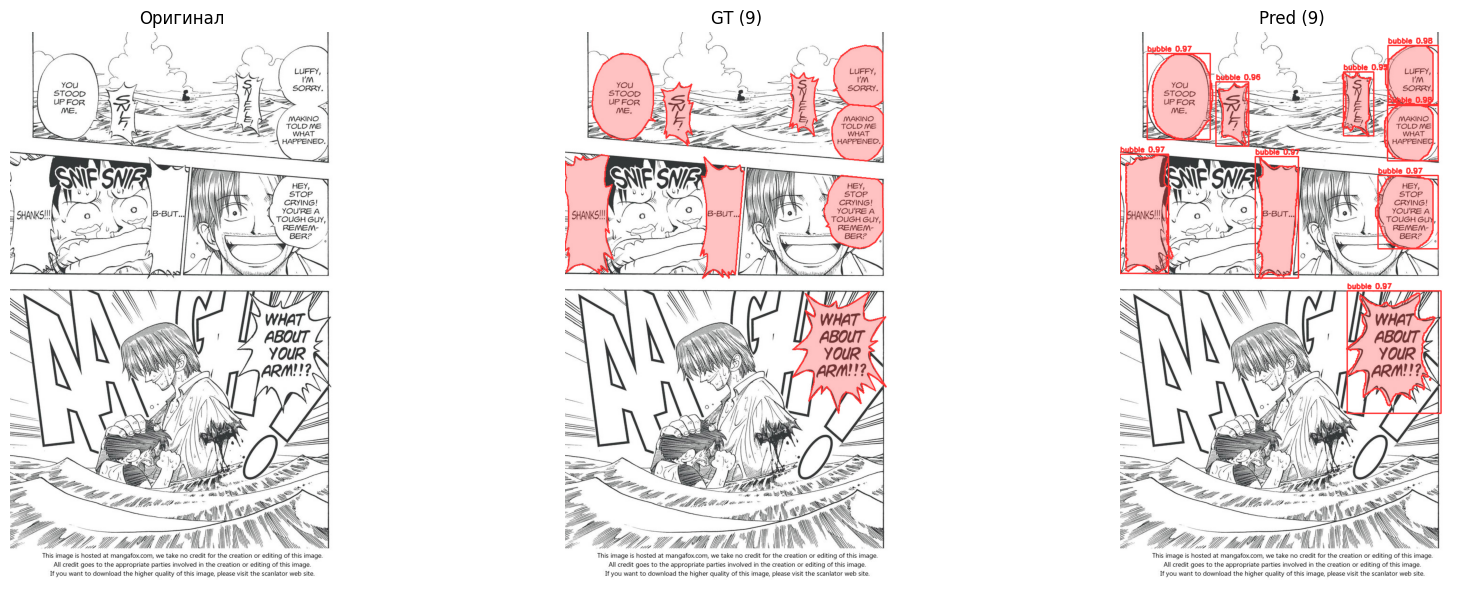

In [9]:
# Тестируем на одиночном изображении
test_img = PATH_TO_IMAGE
test_lbl = r'./dataset/yolo_labels/One Piece (41).txt'

pred = detector.compare_with_gt(
    image_path=test_img,
    label_path=test_lbl
)

In [10]:
detector.save('./model/manga_detector.pt')

clear_memory()

memory cleared


In [24]:
@dataclass
class TextBlock:
    text: str
    confidence: float
    bbox: Tuple[int, int, int, int]


class MangaOCR:
    """
    OCR для манги на EasyOCR.
    Пробует 2 варианта: оригинал и CLAHE + ресайз 300.
    Не очищает текст – чистка перенесена в переводчик.
    Нераспознанные блоки возвращаются с text=" ".
    """

    def __init__(self):
        self.reader = easyocr.Reader(['en'], gpu=True)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        print("🔤 EasyOCR готов")

    def prepare_region(
        self, image: np.ndarray, mask: np.ndarray, bbox: Tuple[int, int, int, int]
    ) -> np.ndarray:
        x1, y1, x2, y2 = map(int, bbox)

        crop = image[y1:y2, x1:x2].copy()
        crop_mask = mask[y1:y2, x1:x2]

        result = np.ones_like(crop) * 255
        result[crop_mask > 0] = crop[crop_mask > 0]

        gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)

        text_mean = cv2.mean(gray, mask=crop_mask.astype(np.uint8))[0]
        bg_mean = cv2.mean(gray, mask=(1 - crop_mask).astype(np.uint8))[0]

        if text_mean > bg_mean:
            gray = 255 - gray

        return gray

    def _to_rgb(self, gray: np.ndarray) -> np.ndarray:
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB) if gray.ndim == 2 else gray

    def _ocr(self, image: np.ndarray) -> Tuple[str, float]:
        results = self.reader.readtext(
            image,
            paragraph=False,
            min_size=5,
            text_threshold=0.4,
            low_text=0.2,
            width_ths=0.5,
        )
        if results:
            texts, confs = [], []
            for _, txt, conf in results:
                txt = txt.strip()
                if txt and conf > 0.2:
                    texts.append(txt)
                    confs.append(conf)
            if texts:
                return ' '.join(texts), np.mean(confs)
        return "", 0.0

    def recognize(self, gray: np.ndarray) -> Tuple[str, float]:
        best_text, best_conf = "", 0.0

        h, w = gray.shape
        scale = 300 / max(h, w) if max(h, w) < 300 else 1.0

        # Вариант 1: оригинал
        v1 = (
            cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
            if scale > 1.0
            else gray
        )
        text, conf = self._ocr(self._to_rgb(v1))
        if conf > best_conf:
            best_text, best_conf = text, conf

        # Вариант 2: CLAHE + ресайз 300
        v2 = self.clahe.apply(gray)
        if scale > 1.0:
            v2 = cv2.resize(v2, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        text, conf = self._ocr(self._to_rgb(v2))
        if conf > best_conf:
            best_text, best_conf = text, conf

        return best_text, best_conf

    def recognize_text(
        self, image: np.ndarray, mask: np.ndarray, bbox: Tuple[int, int, int, int]
    ) -> TextBlock:
        """Всегда возвращает TextBlock. Если текст пуст или слишком короток – text=' '."""
        try:
            gray = self.prepare_region(image, mask, bbox)
            text, conf = self.recognize(gray)
        except Exception:
            text, conf = "", 0.0

        if not text or len(text.strip()) < 2:
            return TextBlock(text=" ", confidence=conf, bbox=bbox)

        return TextBlock(text=text.strip(), confidence=conf, bbox=bbox)

    def extract_all_text(self, image: np.ndarray, objects: list) -> List[TextBlock]:
        blocks = []
        for i, obj in enumerate(objects):
            mask = obj.get('mask')
            bbox = obj.get('bbox')
            if mask is None or mask.sum() < 10:
                blocks.append(TextBlock(text=" ", confidence=0.0, bbox=tuple(bbox) if bbox else (0, 0, 0, 0)))
                print(f"   [{i+1}/{len(objects)}] empty mask → ' '")
                continue

            block = self.recognize_text(image, mask, tuple(bbox))
            status = f'"{block.text[:60]}" ({block.confidence:.2f})' if block.text.strip() != "" else "' ' (empty)"
            print(f"   [{i+1}/{len(objects)}] {status}")
            blocks.append(block)

        n_text = sum(1 for b in blocks if b.text.strip() and b.text != " ")
        print(f"   {n_text}/{len(blocks)} blocks with text")
        return blocks

🔤 EasyOCR готов

📷 One Piece (41).jpg | областей: 9



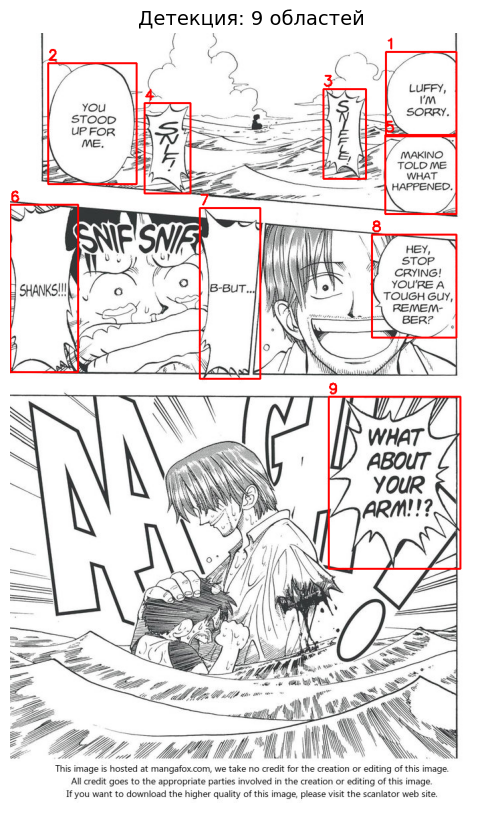

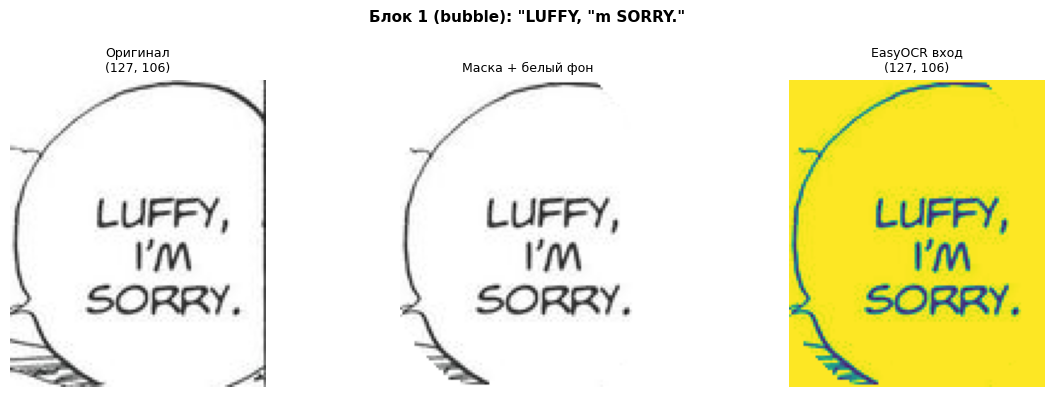

   [1] "LUFFY, "m SORRY."


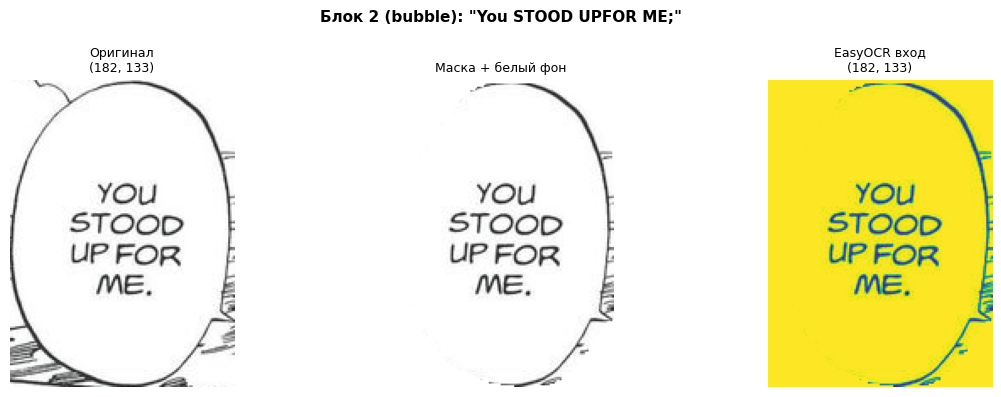

   [2] "You STOOD UPFOR ME;"


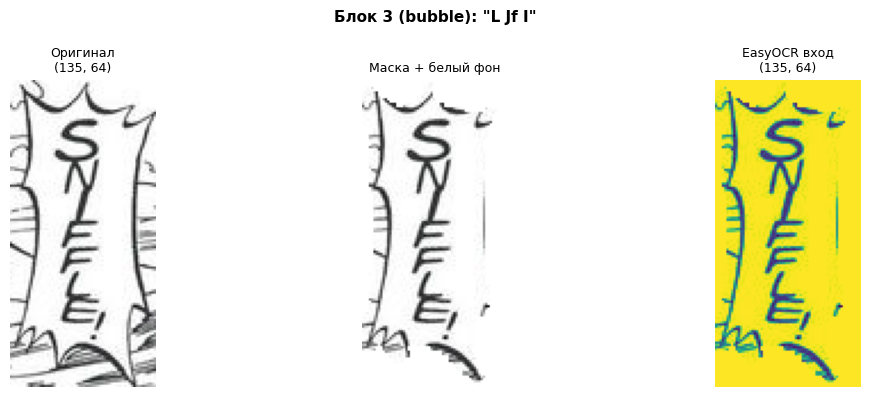

   [3] "L Jf I"


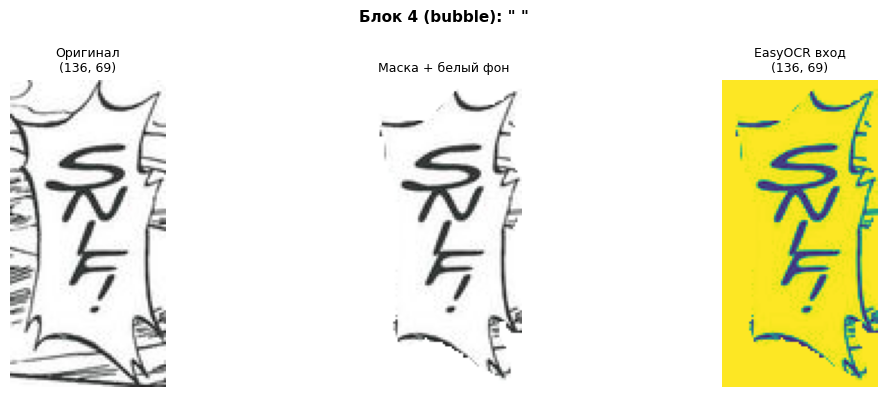

   [4] " "


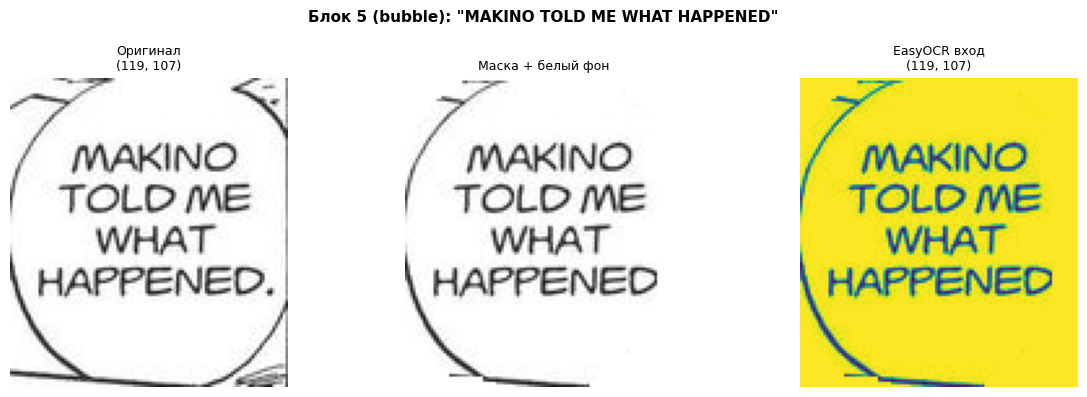

   [5] "MAKINO TOLD ME WHAT HAPPENED"


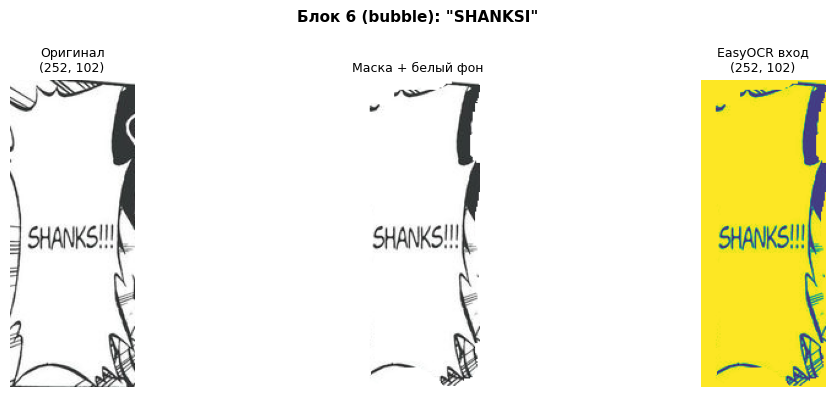

   [6] "SHANKSI"


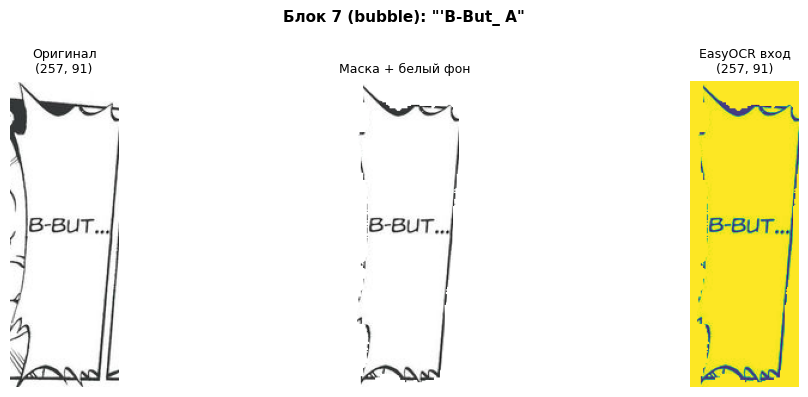

   [7] "'B-But_ A"


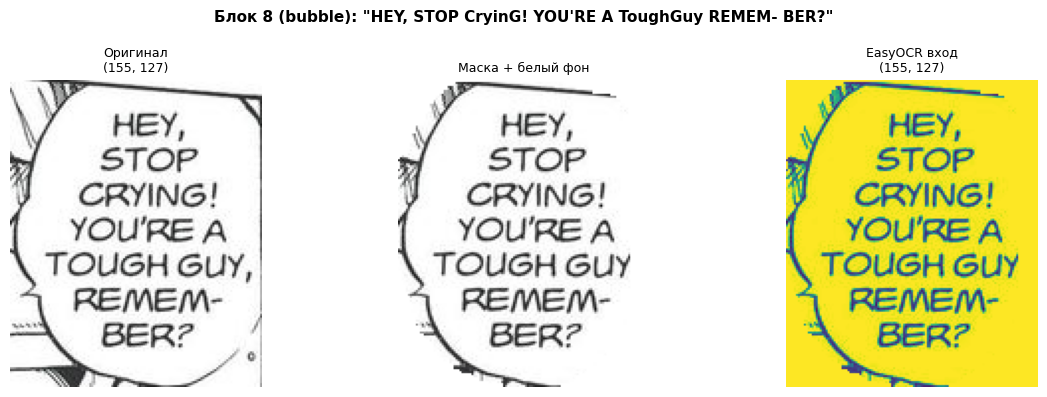

   [8] "HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER?"


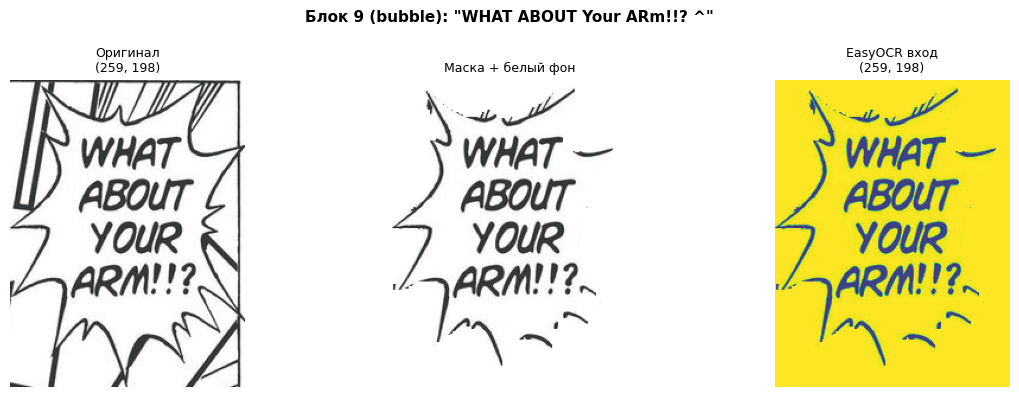

   [9] "WHAT ABOUT Your ARm!!? ^"
   [1/9] "LUFFY, "m SORRY." (0.69)
   [2/9] "You STOOD UPFOR ME;" (0.54)
   [3/9] "L Jf I" (0.64)
   [4/9] ' ' (empty)
   [5/9] "MAKINO TOLD ME WHAT HAPPENED" (0.97)
   [6/9] "SHANKSI" (0.80)
   [7/9] "'B-But_ A" (0.64)
   [8/9] "HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER?" (0.67)
   [9/9] "WHAT ABOUT Your ARm!!? ^" (0.70)
   8/9 blocks with text

📊 9/9 распознано


In [19]:
def validate_pipeline(detector, image_path, ocr, conf=0.25):
    predictions = detector.predict(image_path, conf=conf)
    image = predictions['image']
    objects = predictions['objects']
    n = len(objects)
    
    print(f"\n{'='*60}")
    print(f"📷 {Path(image_path).name} | областей: {n}")
    print(f"{'='*60}\n")
    
    vis = image.copy()
    for i, obj in enumerate(objects):
        x1, y1, x2, y2 = map(int, obj['bbox'])
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(vis, f"{i+1}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(vis)
    plt.title(f'Детекция: {n} областей', fontsize=14)
    plt.axis('off')
    plt.show()
    
    for i, obj in enumerate(objects):
        mask = obj['mask']
        bbox = obj['bbox']
        x1, y1, x2, y2 = map(int, bbox)
        
        crop = image[y1:y2, x1:x2].copy()
        crop_mask = mask[y1:y2, x1:x2]
        
        masked = np.ones_like(crop) * 255
        masked[crop_mask > 0] = crop[crop_mask > 0]
        
        easy_input = ocr.prepare_region(image, mask, tuple(bbox))
        block = ocr.recognize_text(image, mask, tuple(bbox))
        
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(crop)
        axes[0].set_title(f'Оригинал\n{crop.shape[:2]}', fontsize=9)
        axes[0].axis('off')
        
        axes[1].imshow(masked)
        axes[1].set_title('Маска + белый фон', fontsize=9)
        axes[1].axis('off')
        
        axes[2].imshow(easy_input)
        axes[2].set_title(f'EasyOCR вход\n{easy_input.shape[:2]}', fontsize=9)
        axes[2].axis('off')
        
        result = block.text if block else '❌'
        plt.suptitle(f'Блок {i+1} ({obj["class_name"]}): "{result}"', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"   [{i+1}] \"{result}\"")
    
    blocks = ocr.extract_all_text(image, objects)
    print(f"\n📊 {len(blocks)}/{n} распознано")
    return blocks
    
    
ocr = MangaOCR()
blocks = validate_pipeline(detector, PATH_TO_IMAGE, ocr)

In [20]:
@dataclass
class TextBlock:
    text: str
    confidence: float
    bbox: Tuple[int, int, int, int]


class MangaOCR:
    """
    OCR для манги на EasyOCR.
    Работает напрямую с маской пузыря, без bbox.
    Пробует 2 варианта: оригинал и CLAHE + ресайз 300.
    """

    def __init__(self):
        self.reader = easyocr.Reader(['en'], gpu=True)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        print("🔤 EasyOCR готов")

    def prepare_region(self, image: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """
        Извлекает область пузыря по маске.
        Возвращает grayscale изображение, обрезанное до bounding box маски,
        с белым фоном вне маски и с инверсией при необходимости.
        """
        # Координаты bounding box маски
        ys, xs = np.where(mask > 0)
        if len(xs) == 0:
            return np.zeros((1, 1), dtype=np.uint8)
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        # Вырезаем регион с небольшим отступом
        margin = 5
        x1 = max(0, x1 - margin)
        y1 = max(0, y1 - margin)
        x2 = min(image.shape[1], x2 + margin)
        y2 = min(image.shape[0], y2 + margin)

        crop = image[y1:y2, x1:x2].copy()
        crop_mask = mask[y1:y2, x1:x2]

        # Белый фон вне маски
        result = np.ones_like(crop) * 255
        result[crop_mask > 0] = crop[crop_mask > 0]

        # Переводим в серый
        gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)

        # Определяем, нужно ли инвертировать (тёмный текст на светлом фоне или наоборот)
        bg_pixels = gray[crop_mask == 0]
        fg_pixels = gray[crop_mask > 0]
        if len(bg_pixels) > 0 and len(fg_pixels) > 0:
            bg_median = np.median(bg_pixels)
            fg_median = np.median(fg_pixels)
            # Если текст светлее фона — инвертируем
            if fg_median > bg_median:
                gray = 255 - gray

        return gray

    def _to_rgb(self, gray: np.ndarray) -> np.ndarray:
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB) if gray.ndim == 2 else gray

    def _ocr(self, image: np.ndarray) -> Tuple[str, float]:
        results = self.reader.readtext(
            image,
            paragraph=False,
            min_size=5,
            text_threshold=0.4,
            low_text=0.2,
            width_ths=0.5,
        )
        if results:
            texts, confs = [], []
            for _, txt, conf in results:
                txt = txt.strip()
                if txt and conf > 0.2:
                    texts.append(txt)
                    confs.append(conf)
            if texts:
                return ' '.join(texts), np.mean(confs)
        return "", 0.0

    def recognize(self, gray: np.ndarray) -> Tuple[str, float]:
        best_text, best_conf = "", 0.0

        h, w = gray.shape
        scale = 300 / max(h, w) if max(h, w) < 300 else 1.0

        # Вариант 1: оригинал (только ресайз при необходимости)
        v1 = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC) if scale > 1.0 else gray
        text, conf = self._ocr(self._to_rgb(v1))
        if conf > best_conf:
            best_text, best_conf = text, conf

        # Вариант 2: CLAHE + ресайз
        v2 = self.clahe.apply(gray)
        if scale > 1.0:
            v2 = cv2.resize(v2, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        text, conf = self._ocr(self._to_rgb(v2))
        if conf > best_conf:
            best_text, best_conf = text, conf

        return best_text, best_conf

    def recognize_text(self, image: np.ndarray, mask: np.ndarray, bbox: Tuple[int, int, int, int]) -> TextBlock:
        """
        Принимает полное изображение и полную маску (размером с изображение).
        Возвращает TextBlock с распознанным текстом.
        """
        try:
            gray = self.prepare_region(image, mask)
            text, conf = self.recognize(gray)
        except Exception:
            text, conf = "", 0.0

        if not text or len(text.strip()) < 2:
            return TextBlock(text=" ", confidence=conf, bbox=bbox)

        return TextBlock(text=text.strip(), confidence=conf, bbox=bbox)

    def extract_all_text(self, image: np.ndarray, objects: list) -> List[TextBlock]:
        blocks = []
        for i, obj in enumerate(objects):
            mask_full = obj.get('mask')          # полная маска
            bbox = obj.get('bbox')
            if mask_full is None or mask_full.sum() < 10:
                blocks.append(TextBlock(text=" ", confidence=0.0,
                                        bbox=tuple(bbox) if bbox else (0, 0, 0, 0)))
                print(f"   [{i+1}/{len(objects)}] empty mask → ' '")
                continue

            # Передаём полную маску, bbox используется только для сохранения в TextBlock
            block = self.recognize_text(image, mask_full, tuple(bbox))
            status = f'"{block.text[:60]}" ({block.confidence:.2f})' if block.text.strip() != "" else "' ' (empty)"
            print(f"   [{i+1}/{len(objects)}] {status}")
            blocks.append(block)

        n_text = sum(1 for b in blocks if b.text.strip() and b.text != " ")
        print(f"   {n_text}/{len(blocks)} blocks with text")
        return blocks

🔤 EasyOCR готов

📷 One Piece (41).jpg | областей: 9



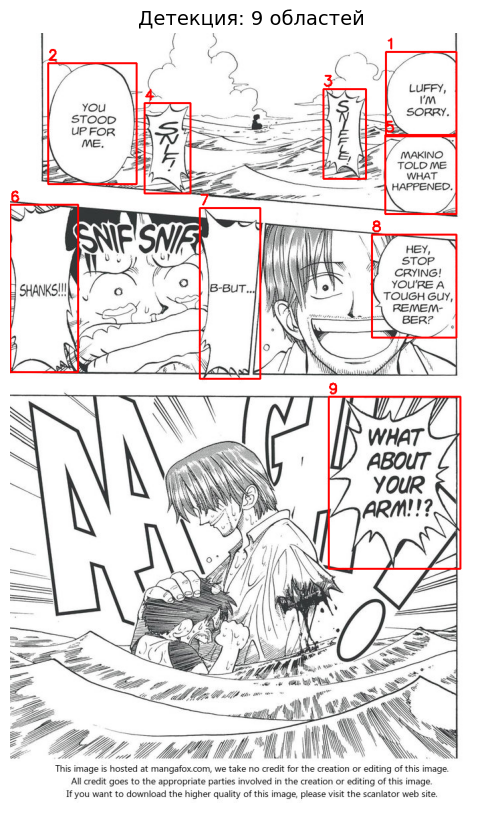

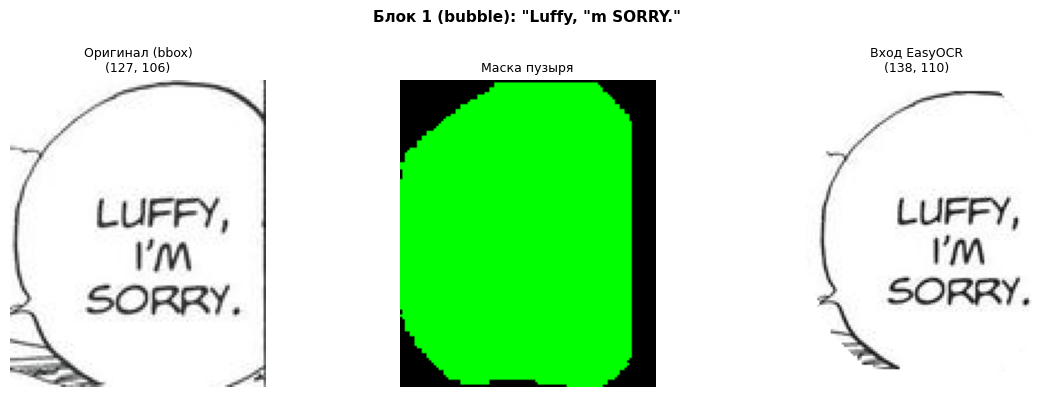

   [1] "Luffy, "m SORRY."


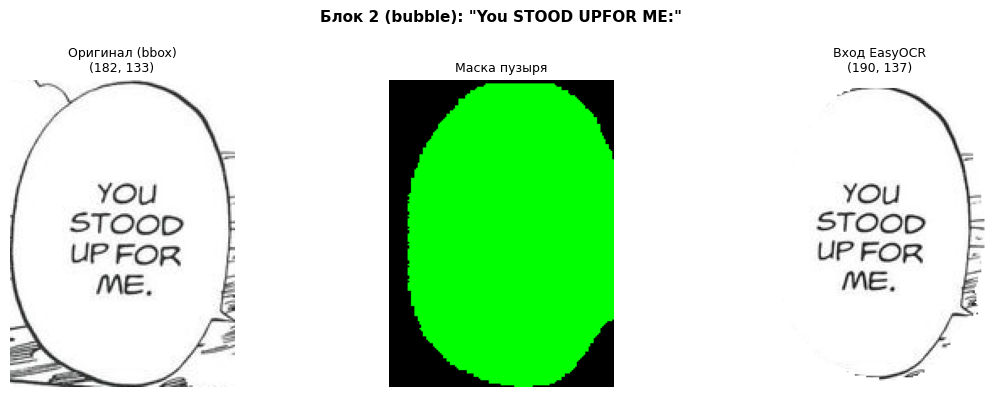

   [2] "You STOOD UPFOR ME:"


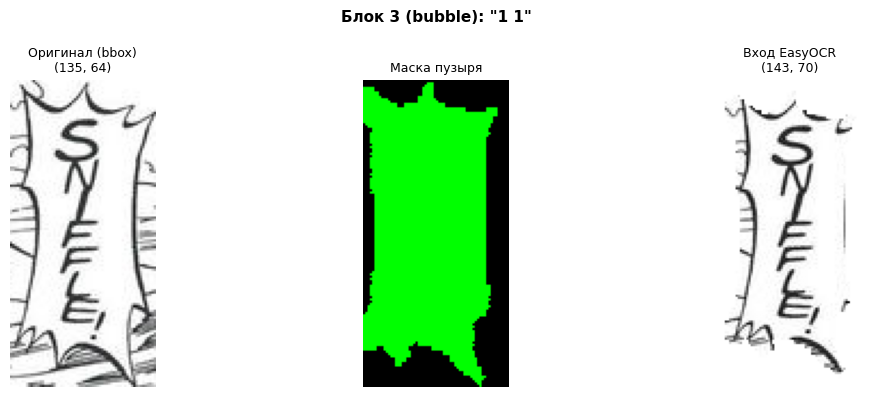

   [3] "1 1"


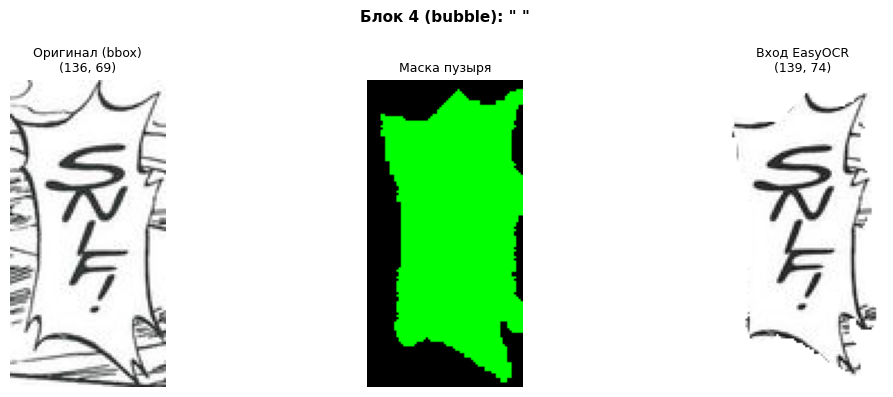

   [4] " "


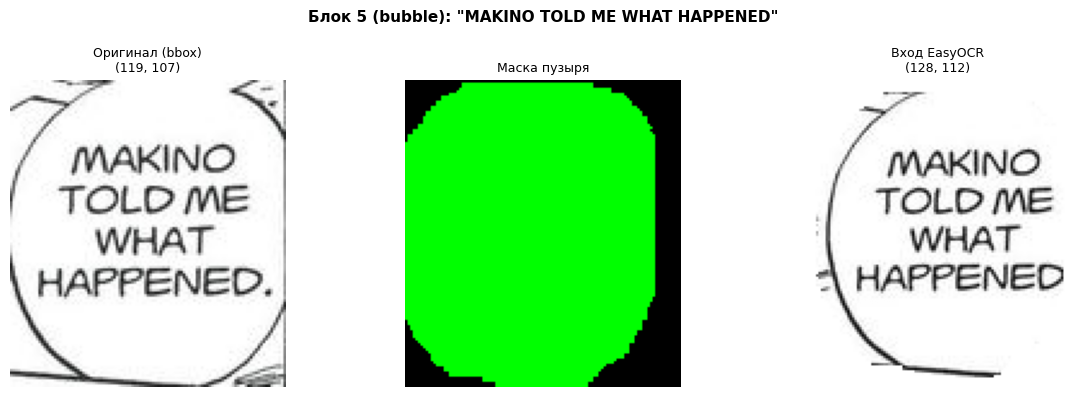

   [5] "MAKINO TOLD ME WHAT HAPPENED"


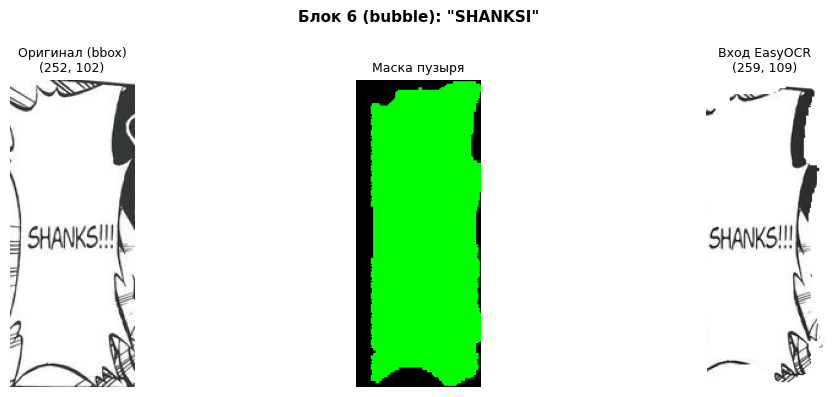

   [6] "SHANKSI"


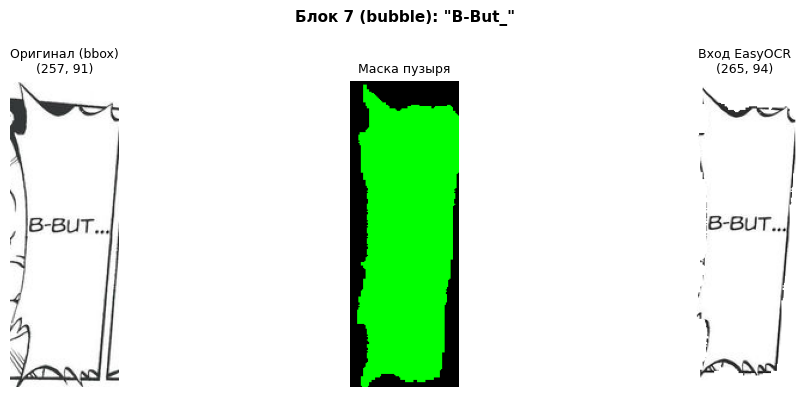

   [7] "B-But_"


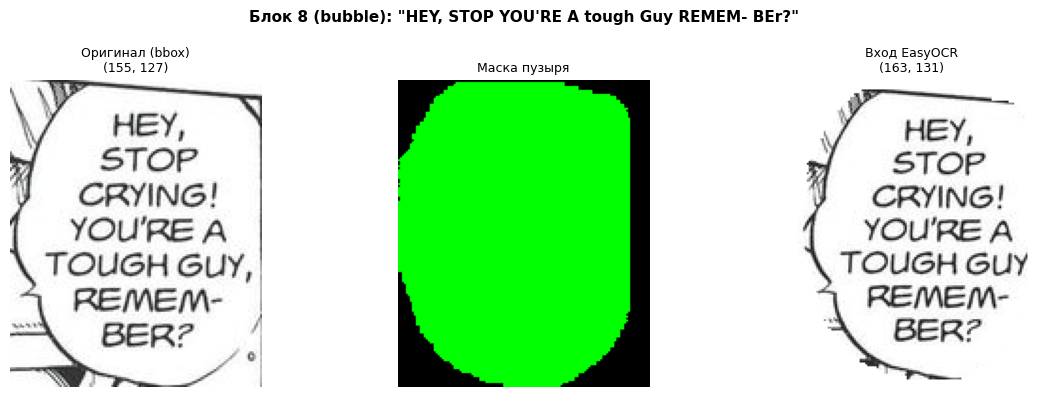

   [8] "HEY, STOP YOU'RE A tough Guy REMEM- BEr?"


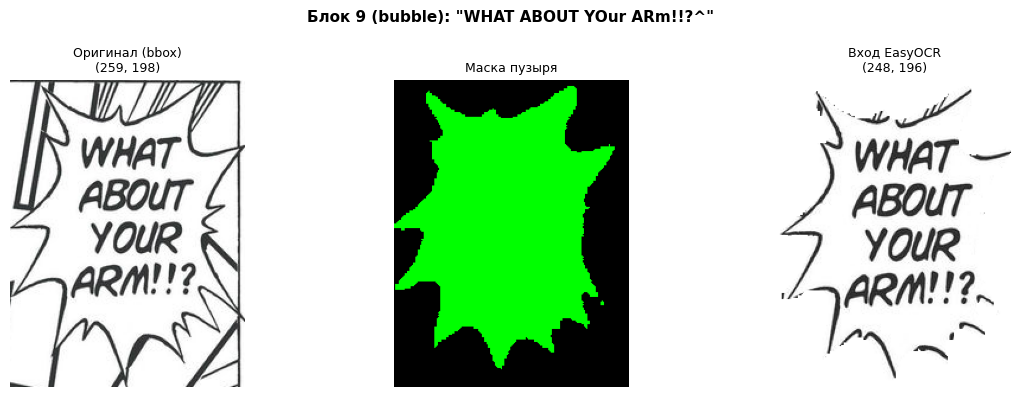

   [9] "WHAT ABOUT YOur ARm!!?^"
   [1/9] "Luffy, "m SORRY." (0.78)
   [2/9] "You STOOD UPFOR ME:" (0.81)
   [3/9] "1 1" (0.61)
   [4/9] ' ' (empty)
   [5/9] "MAKINO TOLD ME WHAT HAPPENED" (0.96)
   [6/9] "SHANKSI" (0.24)
   [7/9] "B-But_" (0.96)
   [8/9] "HEY, STOP YOU'RE A tough Guy REMEM- BEr?" (0.69)
   [9/9] "WHAT ABOUT YOur ARm!!?^" (0.71)
   8/9 blocks with text

📊 9/9 распознано


In [22]:
def validate_pipeline(detector, image_path, ocr, conf=0.25):
    predictions = detector.predict(image_path, conf=conf)
    image = predictions['image']
    objects = predictions['objects']
    n = len(objects)
    
    print(f"\n{'='*60}")
    print(f"📷 {Path(image_path).name} | областей: {n}")
    print(f"{'='*60}\n")
    
    # 1. Оригинал с bbox
    vis = image.copy()
    for i, obj in enumerate(objects):
        x1, y1, x2, y2 = map(int, obj['bbox'])
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(vis, f"{i+1}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(vis)
    plt.title(f'Детекция: {n} областей', fontsize=14)
    plt.axis('off')
    plt.show()
    
    # 2. Для каждого блока
    for i, obj in enumerate(objects):
        mask_full = obj['mask']
        bbox = obj['bbox']
        x1, y1, x2, y2 = map(int, bbox)
        
        crop = image[y1:y2, x1:x2].copy()
        easy_input = ocr.prepare_region(image, mask_full)
        block = ocr.recognize_text(image, mask_full, tuple(bbox))
        
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(crop)
        axes[0].set_title(f'Оригинал (bbox)\n{crop.shape[:2]}', fontsize=9)
        axes[0].axis('off')
        
        # Правильное создание цветной маски
        mask_vis = np.zeros((crop.shape[0], crop.shape[1], 3), dtype=np.uint8)
        mask_vis[mask_full[y1:y2, x1:x2] > 0] = (0, 255, 0)  # зелёный
        axes[1].imshow(mask_vis)
        axes[1].set_title('Маска пузыря', fontsize=9)
        axes[1].axis('off')
        
        axes[2].imshow(easy_input, cmap='gray')
        axes[2].set_title(f'Вход EasyOCR\n{easy_input.shape[:2]}', fontsize=9)
        axes[2].axis('off')
        
        result = block.text if block else '❌'
        plt.suptitle(f'Блок {i+1} ({obj["class_name"]}): "{result}"', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"   [{i+1}] \"{result}\"")
    
    blocks = ocr.extract_all_text(image, objects)
    print(f"\n📊 {len(blocks)}/{n} распознано")
    return blocks

ocr = MangaOCR()
blocks = validate_pipeline(detector, PATH_TO_IMAGE, ocr)

Блок 6: bubble
Размер: (252, 102)
Маска: 20313 px


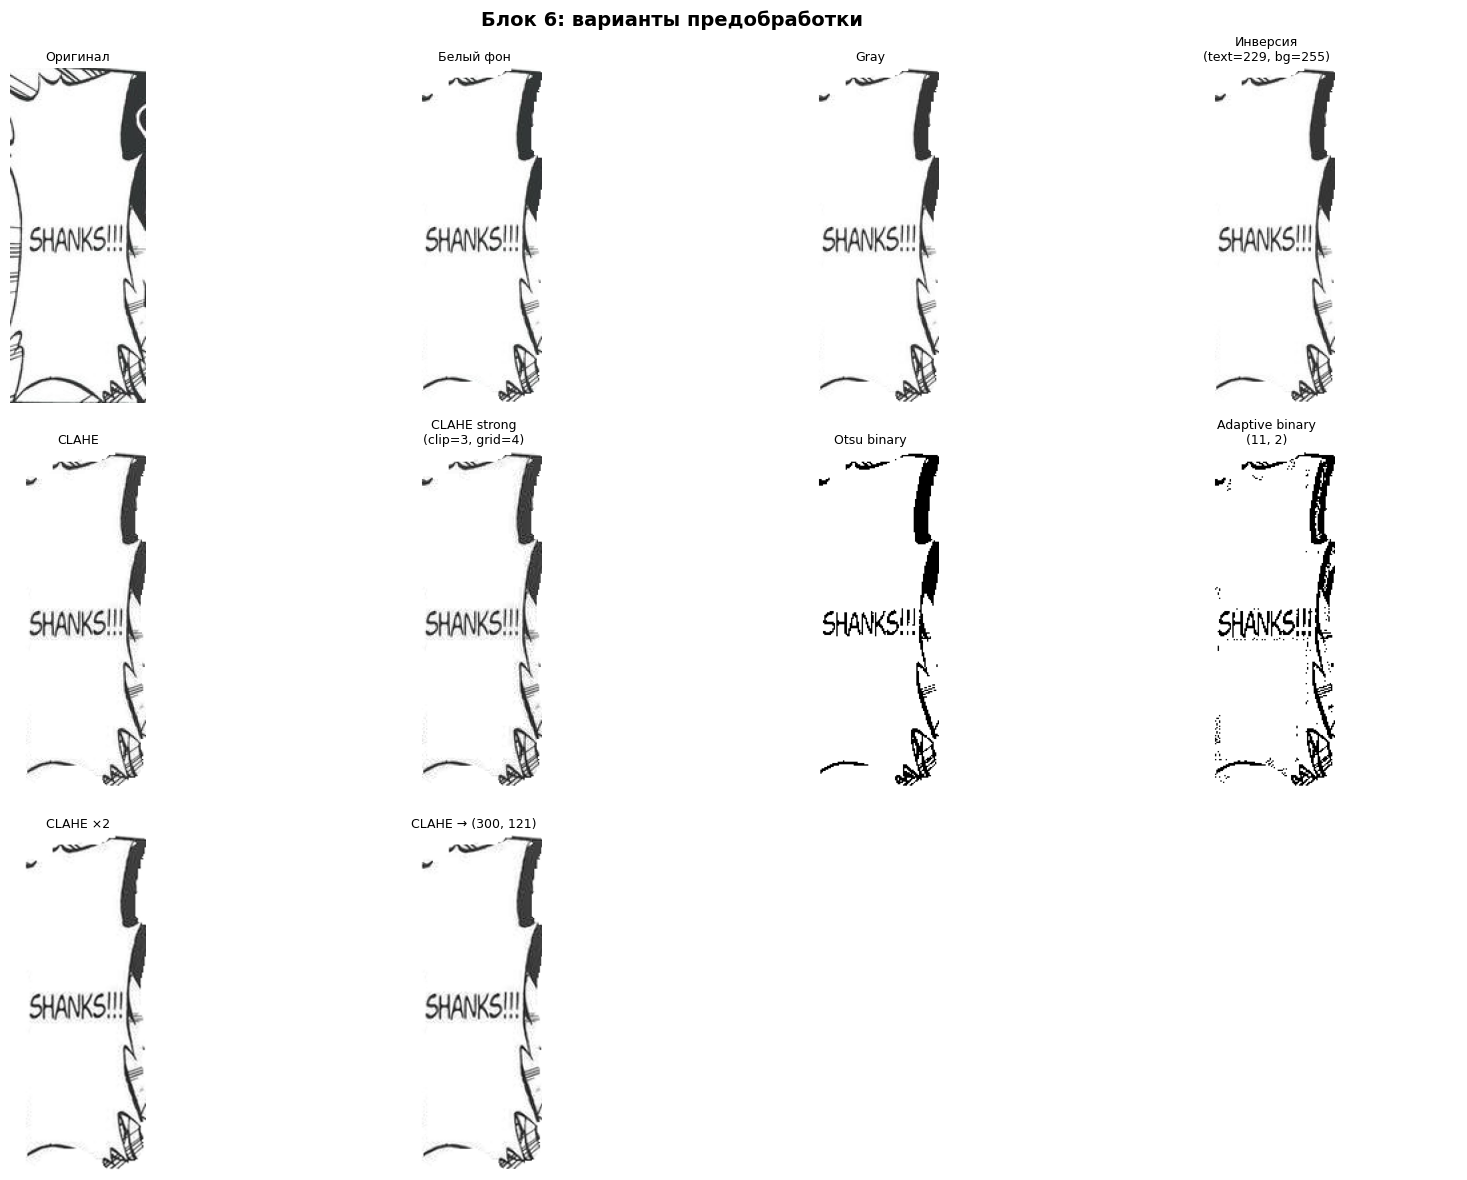


РЕЗУЛЬТАТЫ EasyOCR
  Оригинал                       → "[shanksi"
  Белый фон                      → "SHANKSW"
  Gray                           → "SHANKSW"
  Инверсия
(text=229, bg=255)    → "SHANKSW"
  CLAHE                          → "SHANKSW"
  CLAHE strong
(clip=3, grid=4)  → "SHANKSW"
  Otsu binary                    → "SHANKSI"
  Adaptive binary
(11, 2)        → "SHANksi"
  CLAHE ×2                       → ""
  CLAHE → (300, 121)             → "SHANKSI"
Блок 9: bubble
Размер: (259, 198)
Маска: 26094 px


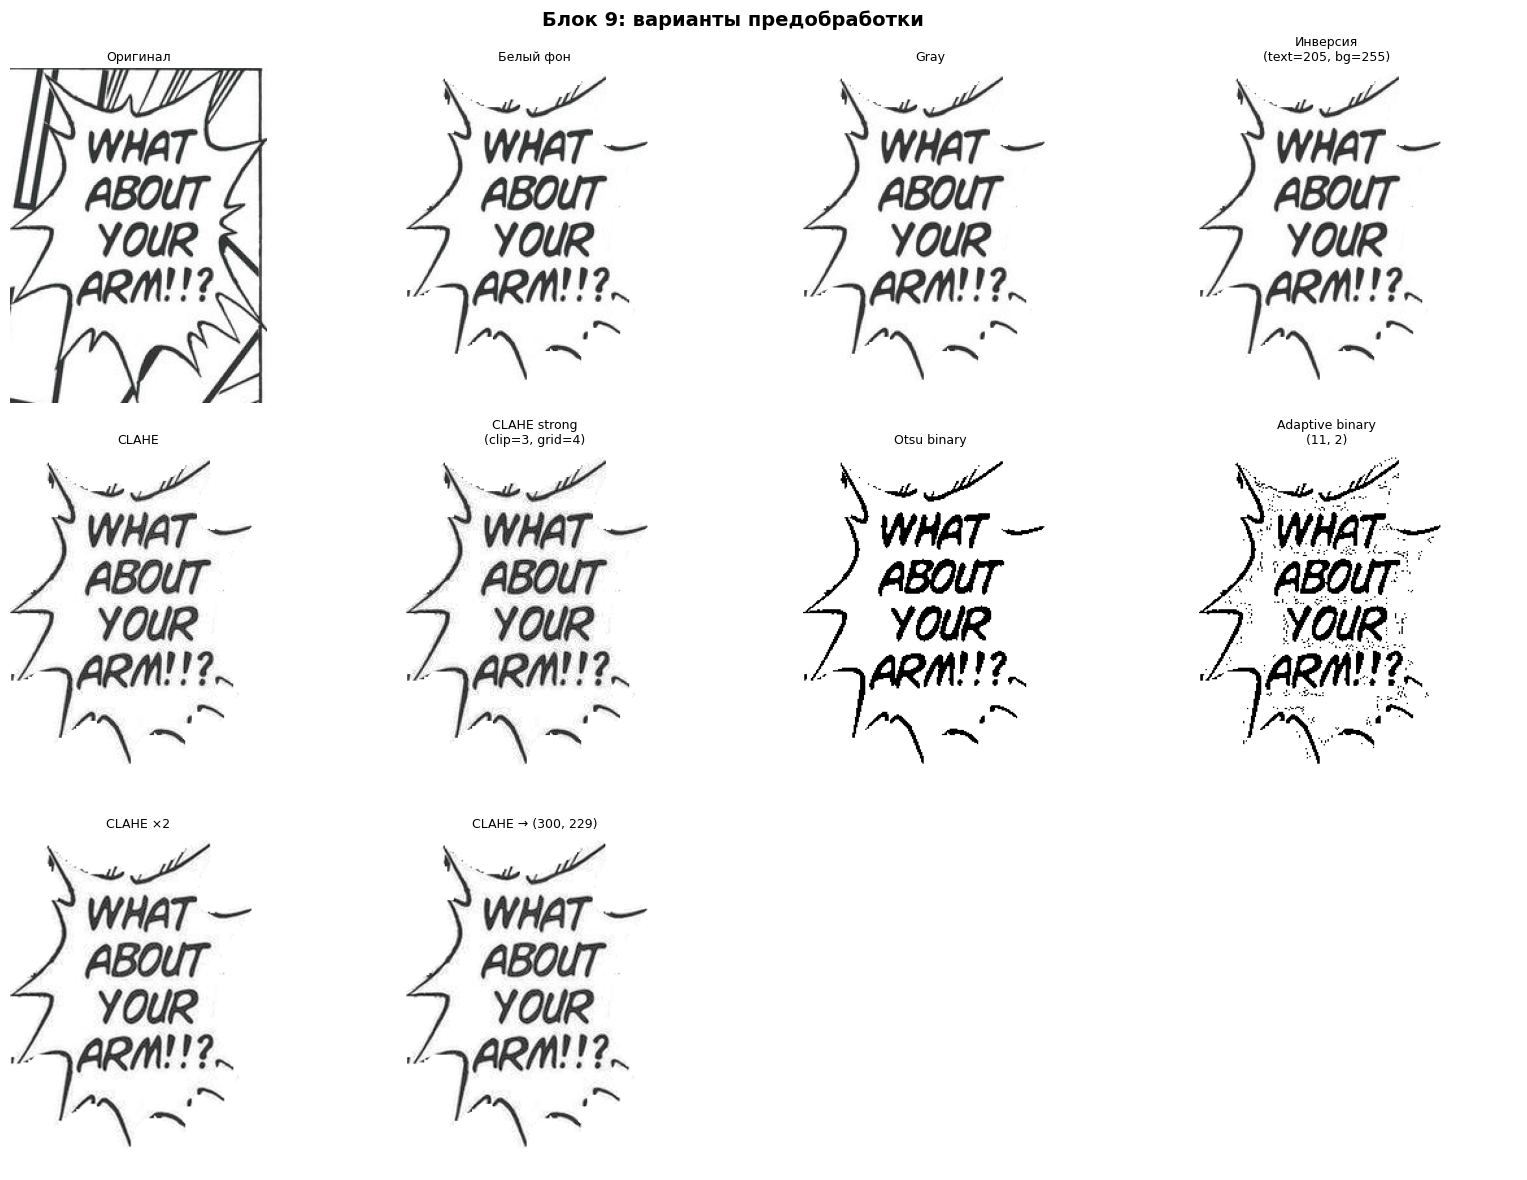


РЕЗУЛЬТАТЫ EasyOCR
  Оригинал                       → "WHAT ABOUT YOur"
  Белый фон                      → "WHAT ABOUT Your"
  Gray                           → "WHAT ABOUT Your"
  Инверсия
(text=205, bg=255)    → "WHAT ABOUT Your"
  CLAHE                          → "WHAT ABOUT Your ARm!i?-"
  CLAHE strong
(clip=3, grid=4)  → "WHAT ABOUT Your ARm!i?-"
  Otsu binary                    → "WHAT ABOUT Your"
  Adaptive binary
(11, 2)        → "4"
  CLAHE ×2                       → "WHAT ABoUT YOUR ArMW!?^"
  CLAHE → (300, 229)             → "WHAT ABOUT YOur ~yW"
Блок 1: bubble
Размер: (127, 106)
Маска: 10922 px


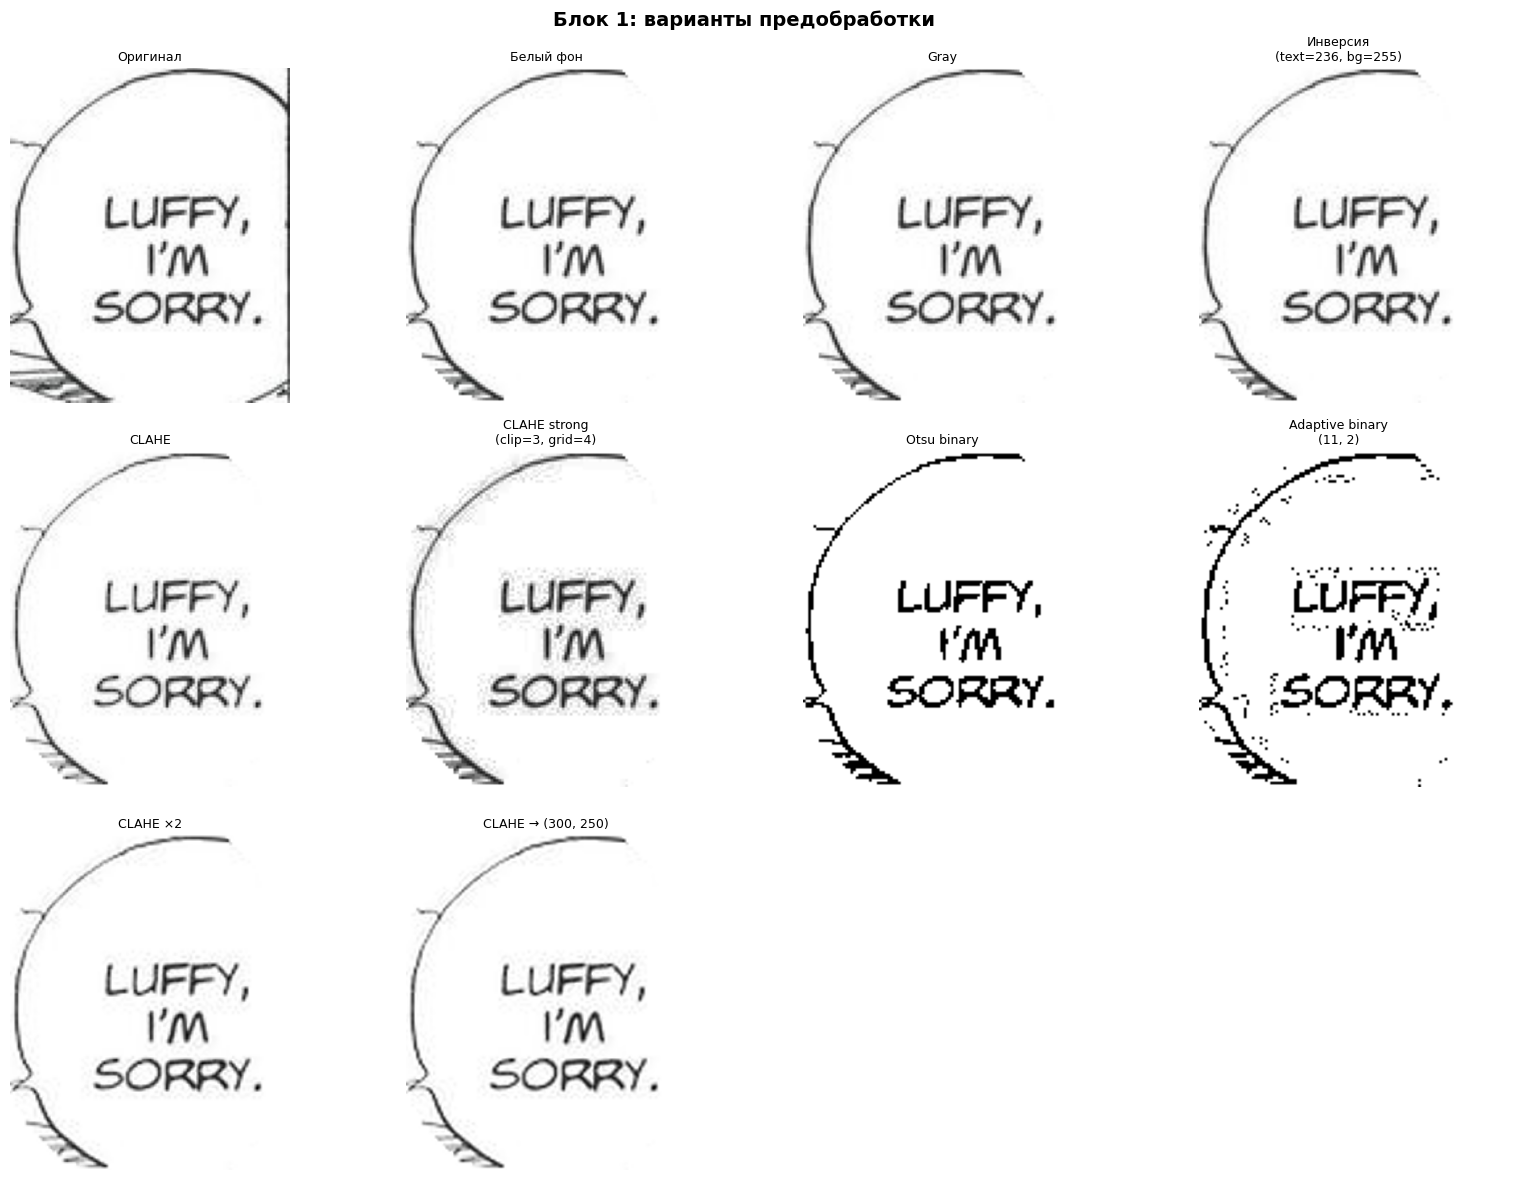


РЕЗУЛЬТАТЫ EasyOCR
  Оригинал                       → "LUFFY, "m SORRY."
  Белый фон                      → "LUFFY, "m SORRY."
  Gray                           → "LUFFY, "m SORRY."
  Инверсия
(text=236, bg=255)    → "LUFFY, "m SORRY."
  CLAHE                          → "LUFFY, "m SORRY."
  CLAHE strong
(clip=3, grid=4)  → "SORRY."
  Otsu binary                    → "Vm SORRY:"
  Adaptive binary
(11, 2)        → "{SORRY ,"
  CLAHE ×2                       → "LUFFY, "m"
  CLAHE → (300, 250)             → "LUFFY, "m SORRY."
Блок 7: bubble
Размер: (257, 91)
Маска: 16812 px


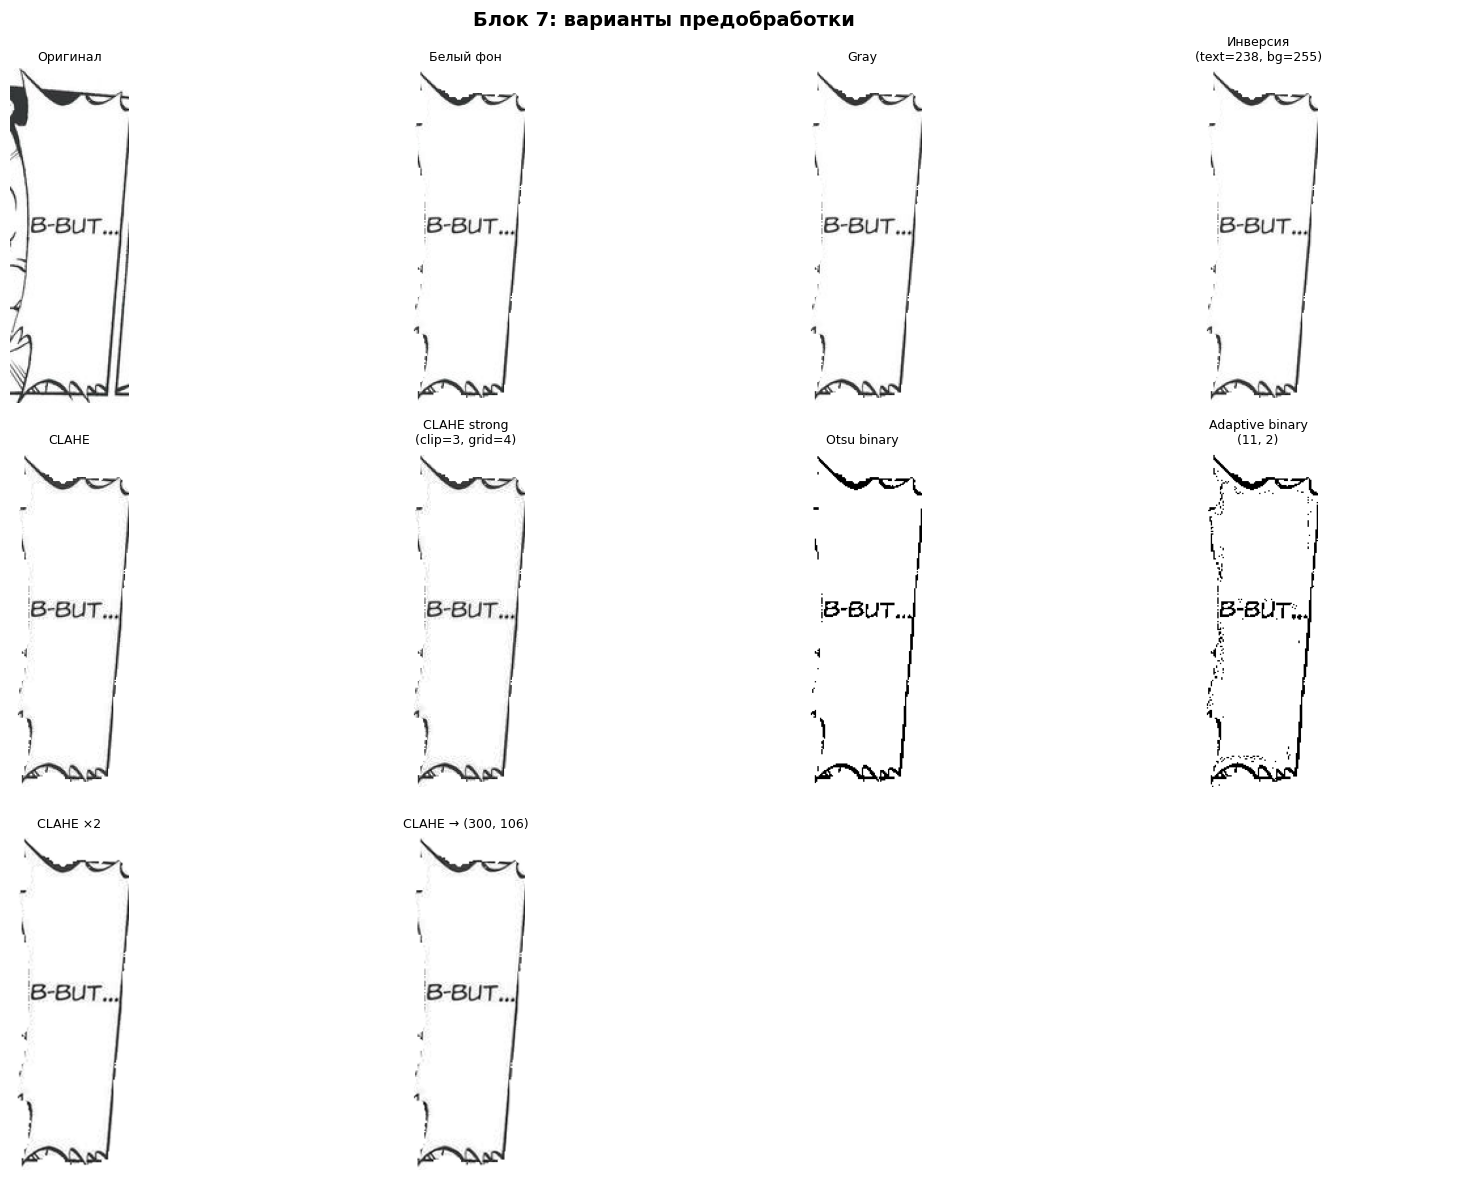


РЕЗУЛЬТАТЫ EasyOCR
  Оригинал                       → "IB-But_|"
  Белый фон                      → ""
  Gray                           → ""
  Инверсия
(text=238, bg=255)    → ""
  CLAHE                          → ""
  CLAHE strong
(clip=3, grid=4)  → ""
  Otsu binary                    → "IB-Bu7."
  Adaptive binary
(11, 2)        → ""
  CLAHE ×2                       → "B-But_|"
  CLAHE → (300, 106)             → "'B-But,"


In [47]:
def debug_preprocessing(detector, image_path, block_idx=0):
    """
    Валидация предобработки: показывает все этапы для одного блока.
    Меняйте параметры и смотрите что получается.
    """
    predictions = detector.predict(image_path, conf=0.25)
    image = predictions['image']
    obj = predictions['objects'][block_idx]
    
    mask = obj['mask']
    bbox = obj['bbox']
    x1, y1, x2, y2 = map(int, bbox)
    
    crop = image[y1:y2, x1:x2].copy()
    crop_mask = mask[y1:y2, x1:x2]
    
    print(f"Блок {block_idx+1}: {obj['class_name']}")
    print(f"Размер: {crop.shape[:2]}")
    print(f"Маска: {crop_mask.sum():.0f} px")

    variants = {}
    
    # 1. Оригинал
    variants['Оригинал'] = crop.copy()
    
    # 2. Белый фон
    white_bg = np.ones_like(crop) * 255
    white_bg[crop_mask > 0] = crop[crop_mask > 0]
    variants['Белый фон'] = white_bg.copy()
    
    # 3. Серый
    gray = cv2.cvtColor(white_bg, cv2.COLOR_RGB2GRAY)
    variants['Gray'] = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    
    # 4. Инверсия
    text_mean = cv2.mean(gray, mask=crop_mask.astype(np.uint8))[0]
    bg_mean = cv2.mean(gray, mask=(1 - crop_mask).astype(np.uint8))[0]
    inverted = 255 - gray if text_mean > bg_mean else gray.copy()
    variants[f'Инверсия\n(text={text_mean:.0f}, bg={bg_mean:.0f})'] = cv2.cvtColor(inverted, cv2.COLOR_GRAY2RGB)
    
    # 5. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(inverted)
    variants['CLAHE'] = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    
    # 6. CLAHE с другими параметрами
    clahe_strong = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    variants['CLAHE strong\n(clip=3, grid=4)'] = cv2.cvtColor(clahe_strong.apply(inverted), cv2.COLOR_GRAY2RGB)
    
    # 7. Бинаризация Otsu
    _, otsu = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants['Otsu binary'] = cv2.cvtColor(otsu, cv2.COLOR_GRAY2RGB)
    
    # 8. Адаптивная бинаризация
    adaptive = cv2.adaptiveThreshold(inverted, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 11, 2)
    variants['Adaptive binary\n(11, 2)'] = cv2.cvtColor(adaptive, cv2.COLOR_GRAY2RGB)
    
    # 9. Ресайз ×2
    h, w = gray.shape
    resized_2x = cv2.resize(clahe_img, (w*2, h*2), interpolation=cv2.INTER_CUBIC)
    variants['CLAHE ×2'] = cv2.cvtColor(resized_2x, cv2.COLOR_GRAY2RGB)
    
    # 10. Ресайз до 300
    scale = 300 / max(h, w)
    resized_300 = cv2.resize(clahe_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    variants[f'CLAHE → {resized_300.shape[:2]}'] = cv2.cvtColor(resized_300, cv2.COLOR_GRAY2RGB)
    
    n = len(variants)
    cols = 4
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()
    
    for i, (name, img) in enumerate(variants.items()):
        axes[i].imshow(img, cmap='gray' if 'binary' in name.lower() or 'gray' in name.lower() else None)
        axes[i].set_title(name, fontsize=9)
        axes[i].axis('off')
    
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Блок {block_idx+1}: варианты предобработки', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ EasyOCR")
    print("="*60)
    
    import easyocr
    reader = easyocr.Reader(['en'], gpu=True)
    
    for name, img in variants.items():
        if len(img.shape) == 2:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = img
        
        results = reader.readtext(img_rgb, paragraph=False, min_size=5, 
                                  text_threshold=0.4, low_text=0.2)
        texts = [r[1].strip() for r in results if r[1].strip() and r[2] > 0.3]
        text = ' '.join(texts)
        
        print(f"  {name[:30]:30s} → \"{text}\"")



debug_preprocessing(detector, PATH_TO_IMAGE, block_idx=5)
debug_preprocessing(detector, PATH_TO_IMAGE, block_idx=8)

debug_preprocessing(detector, PATH_TO_IMAGE, block_idx=0)
debug_preprocessing(detector, PATH_TO_IMAGE, block_idx=6)

In [23]:
class MangaTranslator:
    """
    Переводчик EN→RU через NLLB-200-1.3B.
    Пакетный перевод с точечной предобработкой:
    1. Удаление артефактов (^, ~, _ и т.д.)
    2. Удаление заиканий (B-But → But)
    3. Склеивание переносов (REMEM- BER → REMEMBER)
    4. Нормализация регистра (Title Case)
    5. Исправление конечной пунктуации
    Каждый текст разбивается на предложения, переводится отдельно и собирается обратно.
    """

    def __init__(self, source_lang: str = 'en', target_lang: str = 'ru'):
        self.source_lang = source_lang
        self.target_lang = target_lang

        model_name = "facebook/nllb-200-1.3B"
        print(f"🌐 NLLB-200-1.3B: {source_lang} → {target_lang}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            low_cpu_mem_usage=True
        )

        if torch.cuda.is_available():
            self.model = self.model.cuda()
            print("   ✅ GPU (fp16)")
        else:
            print("   ✅ CPU (fp32)")

        self.src_code = "eng_Latn"
        self.tgt_code = "rus_Cyrl"

    def _get_tgt_token_id(self) -> int:
        tid = self.tokenizer.convert_tokens_to_ids(self.tgt_code)
        if tid != self.tokenizer.unk_token_id:
            return tid
        for token, token_id in self.tokenizer.get_added_vocab().items():
            if token == self.tgt_code:
                return token_id
        return self.tokenizer.unk_token_id

    def _remove_artifacts(self, text: str) -> str:
        allowed = re.compile(r'[^a-zA-Z0-9\s.,!?;:\'\"\-\(\)…–—]')
        return allowed.sub('', text)

    def _fix_stuttering(self, text: str) -> str:
        def _stutter_repl(m: re.Match) -> str:
            prefix = m.group(1)
            word = m.group(2)
            if len(prefix) <= 2 and word.lower().startswith(prefix.lower()):
                return word
            return m.group(0)
        return re.sub(r'\b([A-Za-z]{1,2})-([A-Za-z]{3,})', _stutter_repl, text)

    def _fix_hyphenation(self, text: str) -> str:
        return re.sub(r'(\w)-\s+(\w)', r'\1\2', text)

    def _normalize_case(self, text: str) -> str:
        if not text:
            return text
        sentences = re.split(r'(?<=[.?!])\s+', text)
        normalized = []
        for sent in sentences:
            if not sent:
                continue
            words = sent.split()
            if words:
                words[0] = words[0].capitalize()
                words = [w if w == 'I' else w.lower() for w in words]
                normalized.append(' '.join(words))
        return ' '.join(normalized)

    def _fix_ending_punctuation(self, text: str) -> str:
        if not text:
            return text
        last_punct_match = re.search(r'[^\w\s]+$', text)
        if last_punct_match:
            punct = last_punct_match.group()
            if all(c in '.?!' for c in punct):
                return text
            else:
                return re.sub(r'[^\w\s]+$', '.', text)
        else:
            return text + '.'

    def _preprocess(self, text: str) -> str:
        text = self._remove_artifacts(text)
        text = self._fix_stuttering(text)
        text = self._fix_hyphenation(text)
        text = self._normalize_case(text)
        text = self._fix_ending_punctuation(text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text


    def _split_into_sentences(self, text: str) -> list[str]:
        """Разбивает текст на предложения по .?! и возвращает список строк."""
        sentences = re.split(r'(?<=[.?!])\s+', text)
        return [s.strip() for s in sentences if s.strip()]

    def _postprocess_translation(self, text: str) -> str:
        if not text:
            return text
        text = re.sub(r'\s+([,.!?;:])', r'\1', text)
        text = re.sub(r'([«„(])\s+', r'\1', text)
        text = re.sub(r'\s+([»“)])', r'\1', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def translate_batch(self, texts: list[str]) -> list[str]:
        all_sentences = []
        sentence_map = []

        for text in texts:
            if not text or not text.strip():
                sentence_map.append([])
                continue
            text = self._preprocess(text) 
            sents = self._split_into_sentences(text)
            start_idx = len(all_sentences)
            all_sentences.extend(sents)
            sentence_map.append(list(range(start_idx, len(all_sentences))))

        if not all_sentences:
            return [""] * len(texts)

        self.tokenizer.src_lang = self.src_code
        inputs = self.tokenizer(
            all_sentences,
            return_tensors="pt",
            truncation=True,
            max_length=256,
            padding=True
        )

        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}

        forced_bos = self._get_tgt_token_id()

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                forced_bos_token_id=forced_bos,
                max_length=256,
                num_beams=5,
                early_stopping=True,
                no_repeat_ngram_size=2,
            )

        decoded = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated_sents = [self._postprocess_translation(t.strip()) for t in decoded]

        final_translations = []
        for indices in sentence_map:
            if not indices:
                final_translations.append("")
            else:
                trans_parts = [translated_sents[idx] for idx in indices]
                final_translations.append(' '.join(trans_parts))
        return final_translations

    def translate_blocks(self, text_blocks: list) -> list:
        print(f"\n🌐 Перевод {len(text_blocks)} блоков...")

        texts = []
        for block in text_blocks:
            t = block.text if hasattr(block, 'text') else block.get('text', '')
            texts.append(t.strip() if t else "")

        translated_texts = self.translate_batch(texts)

        results = []
        for i, (block, trans) in enumerate(zip(text_blocks, translated_texts)):
            orig = texts[i] if texts[i] else " "
            results.append({
                'original': orig,
                'translated': trans,
                'confidence': getattr(block, 'confidence', 0.0),
                'bbox': getattr(block, 'bbox', None)
            })
            if i < 10 and orig.strip():
                print(f"   {orig[:60]} → {trans[:60]}")

        print(f"   ✅ {len(results)} блоков")
        return results

In [16]:
def process_page(detector, ocr, translator, image_path, conf=0.25):
    """
    Полный пайплайн: YOLO → OCR → перевод.
    """
    print(f"\n{'='*60}")
    print(f"📄 {Path(image_path).name}")
    print(f"{'='*60}")
    
    print("\n🔍 Детекция...")
    predictions = detector.predict(image_path, conf=conf)
    print(f"   Найдено: {len(predictions['objects'])} областей")
    
    print("\n📖 OCR...")
    text_blocks = ocr.extract_all_text(predictions['image'], predictions['objects'])

    translated = translator.translate_blocks(text_blocks)

    print(f"\n{'='*60}")
    print("📋 РЕЗУЛЬТАТЫ")
    print(f"{'='*60}")
    for i, item in enumerate(translated):
        print(f"\n   [{i+1}] {item['original']}")
        print(f"       → {item['translated']}")
    
    return translated

ocr = MangaOCR()
translator = MangaTranslator(source_lang='en', target_lang='ru')

results = process_page(detector, ocr, translator, PATH_TO_IMAGE)

🔤 EasyOCR готов
🌐 NLLB-200-1.3B: en → ru


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

   ✅ GPU (fp16)

📄 One Piece (41).jpg

🔍 Детекция...
   Найдено: 9 областей

📖 OCR...
   [1/9] "LUFFY, "m SORRY." (0.69)
   [2/9] "You STOOD UPFOR ME;" (0.54)
   [3/9] "L Jf I" (0.64)
   [4/9] ' ' (empty)
   [5/9] "MAKINO TOLD ME WHAT HAPPENED" (0.97)
   [6/9] "SHANKSI" (0.80)
   [7/9] "'B-But_ A" (0.64)
   [8/9] "HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER?" (0.67)
   [9/9] "WHAT ABOUT Your ARm!!? ^" (0.70)
   8/9 blocks with text

🌐 Перевод 9 блоков...
   LUFFY, "m SORRY. → Люфи, прости.
   You STOOD UPFOR ME; → Ты стоял за меня.
   L Jf I → Я знаю.
   MAKINO TOLD ME WHAT HAPPENED → Макино рассказал мне, что случилось.
   SHANKSI → Шэнки.
   'B-But_ A → Но...
   HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER? → Эй, перестань плакать! Ты жесткий парень, помнишь?
   WHAT ABOUT Your ARm!!? ^ → А как же твоя рука?
   ✅ 9 блоков

📋 РЕЗУЛЬТАТЫ

   [1] LUFFY, "m SORRY.
       → Люфи, прости.

   [2] You STOOD UPFOR ME;
       → Ты стоял за меня.

   [3] L Jf I
       → Я знаю.

   [4]  


In [17]:
clear_memory()

memory cleared


In [25]:
class MangaInpainter:
    """
    Удаляет текст, используя точную маску пузыря.
    """
    def __init__(self, white_threshold=240, variance_threshold=50.0,
                 edge_safe_margin=2, text_dilate=2):
        self.white_threshold = white_threshold
        self.variance_threshold = variance_threshold
        self.edge_safe_margin = edge_safe_margin   # на сколько пикселей сужаем маску пузыря
        self.text_dilate = text_dilate             # на сколько расширяем маску текста

    def _get_bubble_background(self, image: np.ndarray, bubble_mask: np.ndarray) -> np.ndarray:
        """Доминирующий цвет фона пузыря (медиана)."""
        inside = image[bubble_mask > 0]
        if len(inside) == 0:
            return np.array([255, 255, 255], dtype=np.uint8)
        gray = cv2.cvtColor(inside.reshape(-1, 1, 3), cv2.COLOR_RGB2GRAY).flatten()
        threshold = np.percentile(gray, 20) if len(gray) > 20 else 0
        bright_mask = gray >= threshold
        if np.sum(bright_mask) < 10:
            return np.median(inside, axis=0).astype(np.uint8)
        return np.median(inside[bright_mask], axis=0).astype(np.uint8)

    def _is_uniform(self, image: np.ndarray, mask: np.ndarray) -> bool:
        """Проверяет однородность фона внутри маски."""
        pixels = image[mask > 0]
        if len(pixels) < 10:
            return True
        return np.std(pixels) < self.variance_threshold

    def inpaint_page(self, image: np.ndarray, blocks: list) -> np.ndarray:
        result = image.copy()
        h, w = result.shape[:2]
        kernel_erode = np.ones((3, 3), np.uint8)
        kernel_dilate = np.ones((3, 3), np.uint8)

        for block in blocks:
            mask_full = block.get('mask')
            bbox = block.get('bbox')
            class_name = block.get('class_name', 'bubble')

            if mask_full is None or mask_full.sum() < 10:
                continue

            x1, y1, x2, y2 = map(int, bbox)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            roi = result[y1:y2, x1:x2]
            roi_mask = mask_full[y1:y2, x1:x2].copy()

            roi_mask_safe = cv2.erode(roi_mask, kernel_erode, iterations=self.edge_safe_margin)

            gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
            _, binary_text = cv2.threshold(gray_roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            text_mask = cv2.bitwise_and(binary_text, binary_text, mask=roi_mask_safe.astype(np.uint8))
            text_mask = cv2.dilate(text_mask, kernel_dilate, iterations=self.text_dilate)
            text_mask = cv2.bitwise_and(text_mask, text_mask, mask=roi_mask_safe.astype(np.uint8))

            if class_name in ('bubble', 'narrative_box') and self._is_uniform(roi, roi_mask):
                bg_color = self._get_bubble_background(roi, roi_mask)
                roi[text_mask > 0] = bg_color
                result[y1:y2, x1:x2] = roi
            else:
                if text_mask.sum() < 10:
                    continue
                roi_inpainted = cv2.inpaint(roi, text_mask, 3, cv2.INPAINT_TELEA)

                result_roi = roi.copy()
                result_roi[roi_mask_safe > 0] = roi_inpainted[roi_mask_safe > 0]
                result[y1:y2, x1:x2] = result_roi

        return result

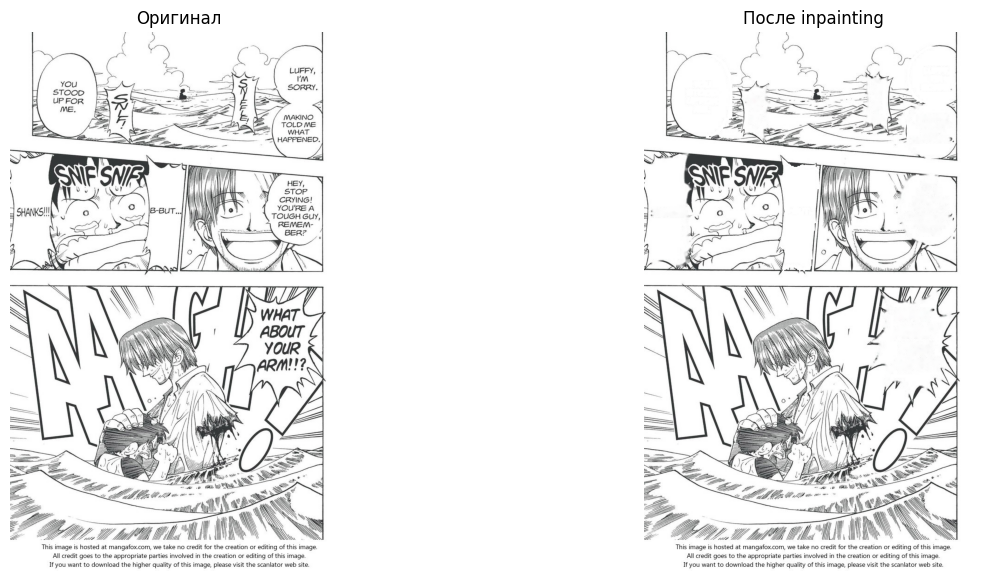

In [19]:
predictions = detector.predict(PATH_TO_IMAGE, conf=0.25)
inpainter = MangaInpainter()
clean = inpainter.inpaint_page(predictions['image'], predictions['objects'])


plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.imshow(predictions['image'])
plt.title('Оригинал')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(clean)
plt.title('После inpainting')
plt.axis('off')
plt.show()

In [34]:
class MangaTextInserter:
    """
    Вставляет переведённый текст в пузыри манги.
    Использует аппроксимацию маски эллипсом для безопасной области вставки.
    """
    def __init__(self, font_path: str = None, outline_width: int = 2,
                 max_font_size: int = 24, min_font_size: int = 6,
                 inner_margin: float = 0.2):
        self.font_path = font_path
        self.outline_width = outline_width
        self.max_font_size = max_font_size
        self.min_font_size = min_font_size
        self.inner_margin = inner_margin  
        self._font_cache = {}
        if font_path:
            try:
                _ = ImageFont.truetype(font_path, size=24)
            except:
                print(f"⚠️ Шрифт {font_path} не найден.")
                self.font_path = None

    def _get_font(self, size: int) -> ImageFont.FreeTypeFont:
        if size not in self._font_cache:
            if self.font_path:
                self._font_cache[size] = ImageFont.truetype(self.font_path, size=size)
            else:
                self._font_cache[size] = ImageFont.load_default()
        return self._font_cache[size]

    def _get_text_color(self, bubble_img: np.ndarray, mask: np.ndarray) -> Tuple[Tuple[int,int,int], Tuple[int,int,int]]:
        if mask is None or mask.sum() == 0:
            return (0,0,0), (255,255,255)
        bg = bubble_img[mask > 0]
        if len(bg) == 0:
            return (0,0,0), (255,255,255)
        gray = cv2.cvtColor(bg.reshape(-1,1,3), cv2.COLOR_RGB2GRAY).ravel()
        med = np.median(gray)
        if med > 128:
            return (0,0,0), (255,255,255)
        else:
            return (255,255,255), (0,0,0)

    def _wrap_text(self, text: str, font: ImageFont.FreeTypeFont, max_width: int) -> List[str]:
        words = text.split()
        if not words:
            return []
        lines = []
        cur_line = []
        cur_w = 0
        space_w = font.getbbox(' ')[2] - font.getbbox(' ')[0]
        for w in words:
            bbox = font.getbbox(w)
            w_w = bbox[2] - bbox[0]
            add = space_w + w_w if cur_line else w_w
            if cur_w + add <= max_width:
                cur_line.append(w)
                cur_w += add
            else:
                if cur_line:
                    lines.append(' '.join(cur_line))
                cur_line = [w]
                cur_w = w_w
        if cur_line:
            lines.append(' '.join(cur_line))
        return lines

    def _get_line_height(self, font: ImageFont.FreeTypeFont) -> int:
        bbox = font.getbbox('Ag')
        return bbox[3] - bbox[1] + 4

    def _fit_text(self, text: str, avail_w: int, avail_h: int, max_font: int = None) -> Tuple[int, List[str]]:
        """Бинарный поиск с ограничением максимального размера."""
        if max_font is None:
            max_font = self.max_font_size
        max_font = min(max_font, avail_h // 2) 
        lo, hi = self.min_font_size, max_font
        best_size = self.min_font_size
        best_lines = []
        
        font = self._get_font(hi)
        lines = self._wrap_text(text, font, avail_w)
        if self._get_line_height(font) * len(lines) <= avail_h:
            return hi, lines
        
        while lo <= hi:
            mid = (lo + hi) // 2
            font = self._get_font(mid)
            lines = self._wrap_text(text, font, avail_w)
            line_h = self._get_line_height(font)
            if line_h * len(lines) <= avail_h:
                best_size = mid
                best_lines = lines
                lo = mid + 1
            else:
                hi = mid - 1
        
        return best_size, best_lines

    def _ellipse_inset(self, mask: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
        """Возвращает (x1, y1, x2, y2) области вставки, основанной на эллипсе."""
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        contour = max(contours, key=cv2.contourArea)
        if len(contour) < 5:
            return None
        try:
            ellipse = cv2.fitEllipse(contour)
        except:
            return None
        (cx, cy), (a, b), angle = ellipse
        new_a = a * (1 - self.inner_margin)
        new_b = b * (1 - self.inner_margin)
        if new_a < 2 or new_b < 2:
            return None
        half_a = new_a / 2
        half_b = new_b / 2
        theta = np.deg2rad(angle)
        cos_t = abs(np.cos(theta))
        sin_t = abs(np.sin(theta))
        half_w = half_a * cos_t + half_b * sin_t
        half_h = half_a * sin_t + half_b * cos_t
        x1 = int(cx - half_w)
        y1 = int(cy - half_h)
        x2 = int(cx + half_w)
        y2 = int(cy + half_h)
        h, w = mask.shape
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = min(w, x2); y2 = min(h, y2)
        if x2 <= x1 or y2 <= y1:
            return None
        return (x1, y1, x2, y2)

    def insert_text(self, image: np.ndarray, blocks: List[dict], translated_blocks: List[dict],
                    max_font_size: int = None) -> np.ndarray:
        result = image.copy()
        h_img, w_img = result.shape[:2]

        for block, trans in zip(blocks, translated_blocks):
            text = trans.get('translated', '')
            if not text or not text.strip():
                continue

            mask_full = block.get('mask')
            bbox = block.get('bbox')
            if mask_full is None or mask_full.sum() < 10 or bbox is None:
                continue

            x1, y1, x2, y2 = map(int, bbox)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w_img, x2), min(h_img, y2)

            bubble_img = result[y1:y2, x1:x2]
            bubble_mask = mask_full[y1:y2, x1:x2].copy()
            bubble_h, bubble_w = bubble_img.shape[:2]

            inset = self._ellipse_inset(bubble_mask)
            if inset is None:
                ys, xs = np.where(bubble_mask > 0)
                if len(xs) == 0: continue
                mx1, mx2 = xs.min(), xs.max()
                my1, my2 = ys.min(), ys.max()
                mask_w = mx2 - mx1
                mask_h = my2 - my1
                margin_w = int(mask_w * self.inner_margin)
                margin_h = int(mask_h * self.inner_margin)
                inset_x1 = max(mx1 + margin_w, 0)
                inset_y1 = max(my1 + margin_h, 0)
                inset_x2 = min(mx2 - margin_w, bubble_w)
                inset_y2 = min(my2 - margin_h, bubble_h)
            else:
                inset_x1, inset_y1, inset_x2, inset_y2 = inset

            avail_w = max(1, inset_x2 - inset_x1)
            avail_h = max(1, inset_y2 - inset_y1)

            effective_max = max_font_size if max_font_size is not None else self.max_font_size
            font_size, lines = self._fit_text(text, avail_w, avail_h, effective_max)
            if not lines:
                continue
            font = self._get_font(font_size)
            line_h = self._get_line_height(font)
            total_h = line_h * len(lines)

            text_color, outline_color = self._get_text_color(bubble_img, bubble_mask)

            text_img = Image.new('RGBA', (bubble_w, bubble_h), (0, 0, 0, 0))
            draw = ImageDraw.Draw(text_img)

            y_start = inset_y1 + (avail_h - total_h) // 2

            r = self.outline_width
            r2 = r * r

            for line in lines:
                line_bbox = font.getbbox(line)
                line_w = line_bbox[2] - line_bbox[0]
                x_line = inset_x1 + (avail_w - line_w) // 2

                if self.outline_width > 0:
                    for dx in range(-r, r+1):
                        for dy in range(-r, r+1):
                            if dx == 0 and dy == 0: continue
                            if dx*dx + dy*dy <= r2:
                                draw.text((x_line+dx, y_start+dy), line,
                                          fill=outline_color+(255,), font=font)
                draw.text((x_line, y_start), line, fill=text_color+(255,), font=font)
                y_start += line_h

            text_arr = np.array(text_img)
            alpha = text_arr[:, :, 3]
            alpha = cv2.bitwise_and(alpha, alpha, mask=bubble_mask.astype(np.uint8))
            text_arr[:, :, 3] = alpha

            alpha_factor = alpha.astype(float)[:, :, np.newaxis] / 255.0
            blended = (bubble_img * (1 - alpha_factor) + text_arr[:, :, :3] * alpha_factor).astype(np.uint8)
            result[y1:y2, x1:x2] = blended

        return result

    def debug_insert(self, image: np.ndarray, block: dict, translated_text: str, max_font_size: int = None):
        mask_full = block.get('mask')
        bbox = block.get('bbox')
        if mask_full is None or bbox is None:
            print("Нет маски или bbox")
            return
        
        x1, y1, x2, y2 = map(int, bbox)
        roi = image[y1:y2, x1:x2].copy()
        roi_mask = mask_full[y1:y2, x1:x2]
        
        temp_image = image.copy()
        fake_blocks = [block]
        fake_trans = [{'translated': translated_text}]
        result_block = self.insert_text(temp_image, fake_blocks, fake_trans, max_font_size)
        
        fig, axes = plt.subplots(1, 4, figsize=(20,5))
        axes[0].imshow(roi)
        axes[0].set_title('Оригинал')
        axes[0].axis('off')
        
        mask_vis = np.zeros_like(roi)
        mask_vis[roi_mask > 0] = 255
        axes[1].imshow(mask_vis, cmap='gray')
        axes[1].set_title('Маска')
        axes[1].axis('off')
        
        inset_vis = roi.copy()
        inset = self._ellipse_inset(roi_mask)
        if inset:
            ix1, iy1, ix2, iy2 = inset
            cv2.rectangle(inset_vis, (ix1, iy1), (ix2, iy2), (0,255,0), 2)
        axes[2].imshow(inset_vis)
        axes[2].set_title('Область вставки (эллипс)')
        axes[2].axis('off')
        
        result_roi = result_block[y1:y2, x1:x2]
        axes[3].imshow(result_roi)
        axes[3].set_title('После вставки')
        axes[3].axis('off')
        plt.tight_layout()
        plt.show()

        inset = self._ellipse_inset(roi_mask)
        if inset:
            ix1, iy1, ix2, iy2 = inset
            avail_w = ix2 - ix1
            avail_h = iy2 - iy1
        else:
            ys, xs = np.where(roi_mask > 0)
            if len(xs) > 0:
                mx1, mx2 = xs.min(), xs.max()
                my1, my2 = ys.min(), ys.max()
                margin_w = int((mx2-mx1)*self.inner_margin)
                margin_h = int((my2-my1)*self.inner_margin)
                avail_w = (mx2 - mx1) - 2*margin_w
                avail_h = (my2 - my1) - 2*margin_h
            else:
                avail_w = avail_h = 1
        effective_max = max_font_size if max_font_size is not None else self.max_font_size
        font_size, lines = self._fit_text(translated_text, avail_w, avail_h, effective_max)
        print(f"Текст: '{translated_text}'")
        print(f"Размер шрифта: {font_size}, строк: {lines}")

In [35]:
clear_memory()

memory cleared


🔤 EasyOCR готов
🌐 NLLB-200-1.3B: en → ru


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

   ✅ GPU (fp16)
   [1/9] "LUFFY, "m SORRY." (0.69)
   [2/9] "You STOOD UPFOR ME;" (0.54)
   [3/9] "L Jf I" (0.64)
   [4/9] ' ' (empty)
   [5/9] "MAKINO TOLD ME WHAT HAPPENED" (0.97)
   [6/9] "SHANKSI" (0.80)
   [7/9] "'B-But_ A" (0.64)
   [8/9] "HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER?" (0.67)
   [9/9] "WHAT ABOUT Your ARm!!? ^" (0.70)
   8/9 blocks with text

🌐 Перевод 9 блоков...
   LUFFY, "m SORRY. → Люфи, прости.
   You STOOD UPFOR ME; → Ты стоял за меня.
   L Jf I → Я знаю.
   MAKINO TOLD ME WHAT HAPPENED → Макино рассказал мне, что случилось.
   SHANKSI → Шэнки.
   'B-But_ A → Но...
   HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER? → Эй, перестань плакать! Ты жесткий парень, помнишь?
   WHAT ABOUT Your ARm!!? ^ → А как же твоя рука?
   ✅ 9 блоков


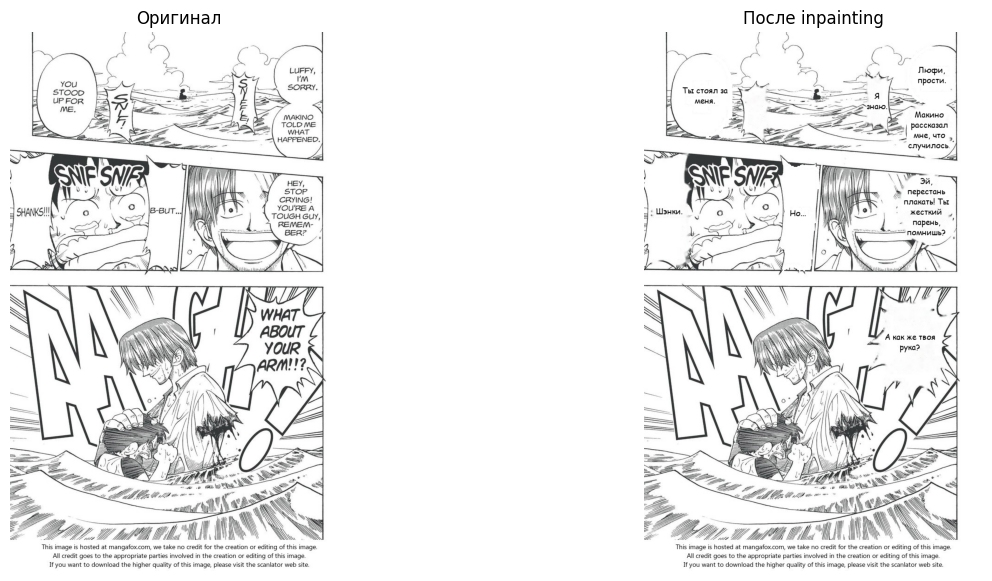

In [36]:
predictions = detector.predict(PATH_TO_IMAGE, conf=0.25)

ocr = MangaOCR()
translator = MangaTranslator(source_lang='en', target_lang='ru')
text_blocks = ocr.extract_all_text(predictions['image'], predictions['objects'])
translated_blocks = translator.translate_blocks(text_blocks)

inpainter = MangaInpainter()
clean_image = inpainter.inpaint_page(predictions['image'], predictions['objects'])
inserter = MangaTextInserter(font_path='./Font/comic.ttf', outline_width=2)
final_image = inserter.insert_text(clean_image, predictions['objects'], translated_blocks, 17)


plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.imshow(predictions['image'])
plt.title('Оригинал')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(final_image)
plt.title('После inpainting')
plt.axis('off')
plt.show()

In [37]:
class MangaTranslationPipeline:
    """Полный пайплайн автоматического перевода манги."""

    def __init__(
        self,
        detector_model_path: str = None,
        detector_model_size: str = 'nano',
        ocr_lang: str = 'en',
        translator_src: str = 'en',
        translator_tgt: str = 'ru',
        font_path: str = None,
        output_dir: str = 'Translation',
        device: str = 'cuda'
    ):
        self.device = device if torch.cuda.is_available() else 'cpu'
        self.detector = MangaBubbleDetector(model_size=detector_model_size)
        if detector_model_path and Path(detector_model_path).exists():
            self.detector.load(detector_model_path)
            print(f"📦 Детектор загружен из {detector_model_path}")
        else:
            print("⚠️ Веса детектора не найдены. Сначала запустите обучение.")
        self.ocr = MangaOCR()
        self.translator = MangaTranslator(source_lang=translator_src, target_lang=translator_tgt)
        self.inpainter = MangaInpainter()
        self.inserter = MangaTextInserter(font_path=font_path, outline_width=2)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        print(f"📁 Результаты будут сохранены в {self.output_dir}")

    def train_detector(self, dataset_path: str, epochs: int = 100, **kwargs):
        """Обучает детектор на датасете."""
        dataset = MangaDataset(dataset_path, split='train')
        yaml_path = str(dataset.data_dir / 'data.yaml')
        self.detector.train(yaml_path=yaml_path, epochs=epochs, **kwargs)
        self.detector.save('manga_detector.pt')
        print("✅ Детектор обучен и сохранён в manga_detector.pt")

    def process_image(self, image_path: str, conf: float = 0.25, save_visualization: bool = False,
                      max_font_size: int = None) -> np.ndarray:
        """
        Обрабатывает одно изображение и возвращает финальную картинку.
        max_font_size – максимальный размер шрифта для вставки (None = авто из класса).
        """
        image_path = Path(image_path)
        print(f"\n{'='*60}")
        print(f"📄 Обработка: {image_path.name}")

        print("🔍 Детекция...")
        predictions = self.detector.predict(str(image_path), conf=conf)
        print(f"   Найдено объектов: {len(predictions['objects'])}")

        print("📖 OCR...")
        text_blocks = self.ocr.extract_all_text(predictions['image'], predictions['objects'])

        print("🌐 Перевод...")
        translated_blocks = self.translator.translate_blocks(text_blocks)

        print("🎨 Удаление текста...")
        clean_image = self.inpainter.inpaint_page(predictions['image'], predictions['objects'])

        print("📝 Вставка перевода...")
        final_image = self.inserter.insert_text(clean_image, predictions['objects'],
                                                translated_blocks, max_font_size=max_font_size)

        out_name = image_path.stem + "_translated" + image_path.suffix
        out_path = self.output_dir / out_name
        cv2.imwrite(str(out_path), cv2.cvtColor(final_image, cv2.COLOR_RGB2BGR))
        print(f"✅ Сохранено: {out_path}")

        if save_visualization:
            self._visualize(predictions['image'], final_image, image_path.name)

        return final_image

    def process_folder(self, folder_path: str, conf: float = 0.25,
                       extensions: tuple = ('.jpg', '.jpeg', '.png', '.webp'),
                       max_font_size: int = None) -> List[Path]:
        """Обрабатывает все изображения в папке."""
        folder = Path(folder_path)
        image_files = []
        for ext in extensions:
            image_files.extend(folder.glob(f'*{ext}'))
            image_files.extend(folder.glob(f'*{ext.upper()}'))

        if not image_files:
            print(f"❌ Не найдено изображений в {folder_path}")
            return []

        print(f"📚 Найдено {len(image_files)} изображений")
        results = []
        for img_path in sorted(image_files):
            try:
                final = self.process_image(str(img_path), conf=conf, max_font_size=max_font_size)
                results.append(final)
            except Exception as e:
                print(f"❌ Ошибка при обработке {img_path.name}: {e}")
        return results

    def _visualize(self, original: np.ndarray, translated: np.ndarray, title: str):
        """Показывает сравнение оригинала и перевода."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
        ax1.imshow(original)
        ax1.set_title('Оригинал', fontsize=14)
        ax1.axis('off')
        ax2.imshow(translated)
        ax2.set_title('Перевод', fontsize=14)
        ax2.axis('off')
        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

In [38]:
pipeline = MangaTranslationPipeline(
    detector_model_path=r'./model/manga_detector.pt',  
    detector_model_size='small',
    font_path=r'./Font/comic.ttf',          
    output_dir='Translation'
)

# Обработка одного изображения
final = pipeline.process_image(PATH_TO_IMAGE, conf=0.25)

# Или всей папки
# pipeline.process_folder('./image', conf=0.25)

🚀 Детектор YOLOv8-small-seg | cuda
📂 Модель загружена: model\manga_detector.pt
📦 Детектор загружен из ./model/manga_detector.pt
🔤 EasyOCR готов
🌐 NLLB-200-1.3B: en → ru


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

   ✅ GPU (fp16)
📁 Результаты будут сохранены в Translation

📄 Обработка: One Piece (41).jpg
🔍 Детекция...
   Найдено объектов: 9
📖 OCR...
   [1/9] "LUFFY, "m SORRY." (0.69)
   [2/9] "You STOOD UPFOR ME;" (0.54)
   [3/9] "L Jf I" (0.64)
   [4/9] ' ' (empty)
   [5/9] "MAKINO TOLD ME WHAT HAPPENED" (0.97)
   [6/9] "SHANKSI" (0.80)
   [7/9] "'B-But_ A" (0.64)
   [8/9] "HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER?" (0.67)
   [9/9] "WHAT ABOUT Your ARm!!? ^" (0.70)
   8/9 blocks with text
🌐 Перевод...

🌐 Перевод 9 блоков...
   LUFFY, "m SORRY. → Люфи, прости.
   You STOOD UPFOR ME; → Ты стоял за меня.
   L Jf I → Я знаю.
   MAKINO TOLD ME WHAT HAPPENED → Макино рассказал мне, что случилось.
   SHANKSI → Шэнки.
   'B-But_ A → Но...
   HEY, STOP CryinG! YOU'RE A ToughGuy REMEM- BER? → Эй, перестань плакать! Ты жесткий парень, помнишь?
   WHAT ABOUT Your ARm!!? ^ → А как же твоя рука?
   ✅ 9 блоков
🎨 Удаление текста...
📝 Вставка перевода...
✅ Сохранено: Translation\One Piece (41)_translated.